In [1]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

file_path = r"D:\MSC THESIS AAVAS\AFTER MID DEFENSE\Final data with IRI\data_for_modeling_with_IRI.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (130, 10)


,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type,IRI
0,1,57.0,1.27,inf,5.5,0.9,Gravel,0.9,Gravel,3.70
1,2,33.0,2.92,46.0,5.5,0.9,Gravel,0.9,Gravel,4.51
2,3,43.0,7.97,inf,5.5,0.9,Gravel,0.9,Gravel,4.39
3,4,48.0,2.07,inf,5.5,0.9,Gravel,0.9,Gravel,4.69
4,5,36.0,1.21,16.0,5.5,0.9,Gravel,0.9,Gravel,5.57


In [3]:
# ============================================================
# STEP 3: INITIAL DATA INSPECTION
# ============================================================

print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape:
(130, 10)

Columns:
['SN', 'V85 Speed', 'Gradient', 'Radius of Curve', 'Carriageway Width', 'Left Shoulder Width', 'Left Shoulder Type', 'Right Shoulder Width', 'Right Shoulder Type', 'IRI']

First 5 rows:


,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type,IRI
0,1,57.0,1.27,inf,5.5,0.9,Gravel,0.9,Gravel,3.70
1,2,33.0,2.92,46.0,5.5,0.9,Gravel,0.9,Gravel,4.51
2,3,43.0,7.97,inf,5.5,0.9,Gravel,0.9,Gravel,4.39
3,4,48.0,2.07,inf,5.5,0.9,Gravel,0.9,Gravel,4.69
4,5,36.0,1.21,16.0,5.5,0.9,Gravel,0.9,Gravel,5.57



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SN                    130 non-null    int64  
 1   V85 Speed             130 non-null    float64
 2   Gradient              130 non-null    float64
 3   Radius of Curve       130 non-null    float64
 4   Carriageway Width     130 non-null    float64
 5   Left Shoulder Width   130 non-null    float64
 6   Left Shoulder Type    130 non-null    str    
 7   Right Shoulder Width  130 non-null    float64
 8   Right Shoulder Type   130 non-null    str    
 9   IRI                   130 non-null    float64
dtypes: float64(7), int64(1), str(2)
memory usage: 10.3 KB

Missing values:
SN                      0
V85 Speed               0
Gradient                0
Radius of Curve         0
Carriageway Width       0
Left Shoulder Width     0
Left Shoulder Type      0
Right Shoulder

In [4]:
# ============================================================
# STEP 4: CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()

print(df.columns.tolist())

['SN', 'V85 Speed', 'Gradient', 'Radius of Curve', 'Carriageway Width', 'Left Shoulder Width', 'Left Shoulder Type', 'Right Shoulder Width', 'Right Shoulder Type', 'IRI']


In [5]:
# ============================================================
# STEP 5: TREAT TANGENT SECTIONS
# infinity --> 1500 m
# ============================================================

radius_original = (
    df["Radius of Curve"]
    .astype(str)
    .str.strip()
    .str.lower()
)

tangent_mask = radius_original.isin(
    ["infinity", "inf", "∞"]
)

print("Number of tangent sections:")
print(tangent_mask.sum())

# Replace tangent sections
df.loc[tangent_mask, "Radius of Curve"] = 1500

# Convert radius column to numeric
df["Radius of Curve"] = pd.to_numeric(
    df["Radius of Curve"],
    errors="coerce"
)

print("\nNumber of Radius = 1500 observations:")
print((df["Radius of Curve"] == 1500).sum())

print("\nRadius summary:")
print(df["Radius of Curve"].describe())

Number of tangent sections:
46

Number of Radius = 1500 observations:
46

Radius summary:
count     130.000000
mean      595.953846
std       675.207219
min        15.000000
25%        55.000000
50%       150.000000
75%      1500.000000
max      1500.000000
Name: Radius of Curve, dtype: float64


In [6]:
# ============================================================
# STEP 6: CLEAN SHOULDER TYPE CATEGORIES
# ============================================================

df["Left Shoulder Type"] = (
    df["Left Shoulder Type"]
    .astype("string")
    .str.strip()
    .str.title()
)

df["Right Shoulder Type"] = (
    df["Right Shoulder Type"]
    .astype("string")
    .str.strip()
    .str.title()
)

print("Left Shoulder Type:")
print(df["Left Shoulder Type"].value_counts())

print("\nRight Shoulder Type:")
print(df["Right Shoulder Type"].value_counts())

Left Shoulder Type:
Left Shoulder Type
Gravel    57
Absent    41
Paved     32
Name: count, dtype: Int64

Right Shoulder Type:
Right Shoulder Type
Gravel    49
Paved     42
Absent    39
Name: count, dtype: Int64


In [7]:
# ============================================================
# STEP 7: CONVERT NUMERIC COLUMNS
# ============================================================

numeric_columns = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[numeric_columns].dtypes)

print("\nMissing values after conversion:")
print(df[numeric_columns].isnull().sum())

V85 Speed               float64
Gradient                float64
Radius of Curve         float64
Carriageway Width       float64
Left Shoulder Width     float64
Right Shoulder Width    float64
IRI                     float64
dtype: object

Missing values after conversion:
V85 Speed               0
Gradient                0
Radius of Curve         0
Carriageway Width       0
Left Shoulder Width     0
Right Shoulder Width    0
IRI                     0
dtype: int64


In [8]:
# ============================================================
# STEP 8: ABSOLUTE GRADIENT
# ============================================================

df["Gradient"] = df["Gradient"].abs()

print(df["Gradient"].describe())

count    130.000000
mean       3.819304
std        2.585841
min        0.100000
25%        1.365000
50%        3.625000
75%        5.975000
max       10.000000
Name: Gradient, dtype: float64


In [9]:
# ============================================================
# STEP 9: DESCRIPTIVE STATISTICS
# ============================================================

eda_variables = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

descriptive_stats = (
    df[eda_variables]
    .describe()
    .T
)

display(descriptive_stats.round(3))

,count,mean,std,min,25%,50%,75%,max
V85 Speed,130.0,47.178,10.399,24.00,42.000,47.250,55.375,74.00
Gradient,130.0,3.819,2.586,0.10,1.365,3.625,5.975,10.00
Radius of Curve,130.0,595.954,675.207,15.00,55.000,150.000,1500.000,1500.00
Carriageway Width,130.0,6.247,0.949,4.70,5.390,7.000,7.000,8.00
Left Shoulder Width,130.0,0.475,0.392,0.00,0.000,0.500,0.900,1.13
Right Shoulder Width,130.0,0.484,0.386,0.00,0.000,0.500,0.900,1.18
IRI,130.0,6.991,2.253,3.63,5.060,6.865,9.152,12.05


In [10]:
# ============================================================
# STEP 10: SKEWNESS
# ============================================================

skewness = (
    df[eda_variables]
    .skew()
    .sort_values(ascending=False)
)

skewness_table = pd.DataFrame({
    "Variable": skewness.index,
    "Skewness": skewness.values
})

display(skewness_table.round(3))

,Variable,Skewness
0,Radius of Curve,0.587
1,Gradient,0.427
2,IRI,0.297
3,Left Shoulder Width,0.027
4,Right Shoulder Width,-0.016
5,V85 Speed,-0.081
6,Carriageway Width,-0.323


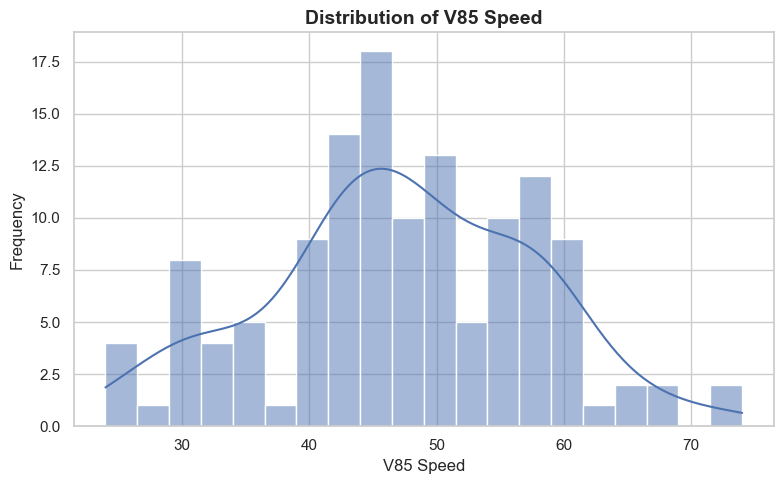

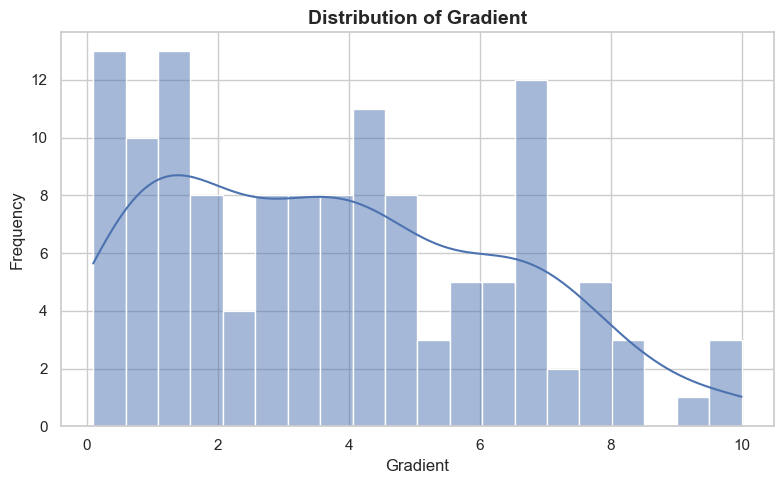

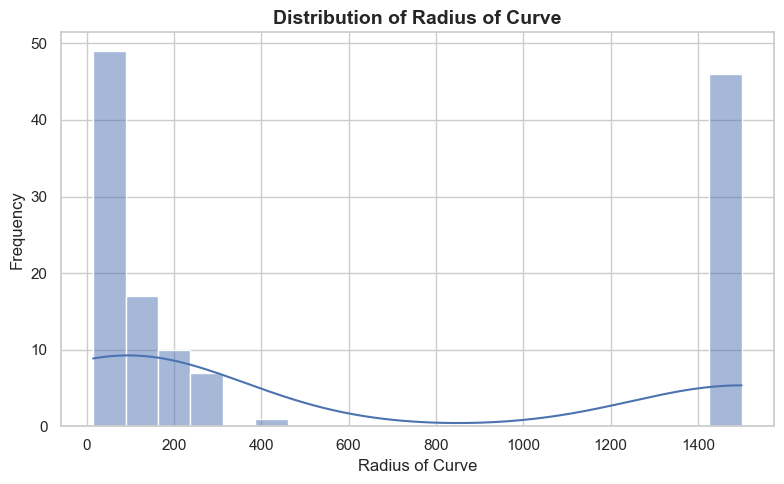

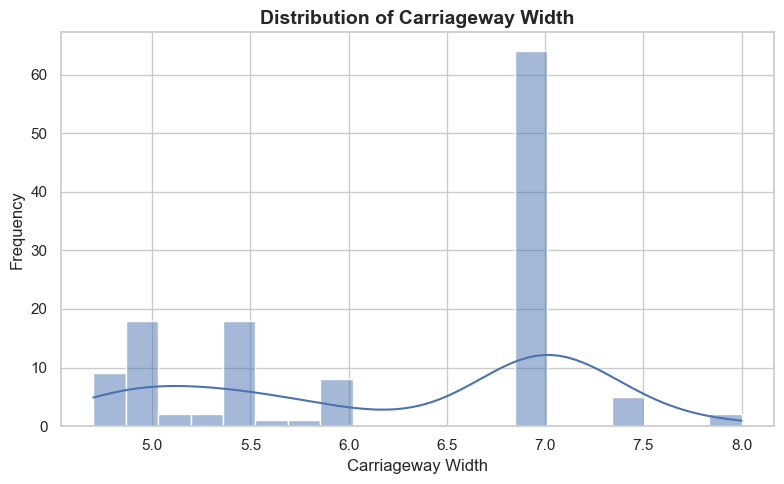

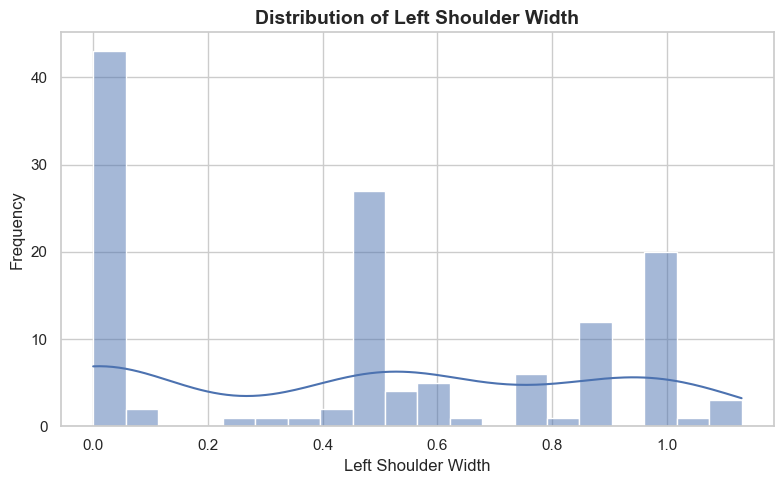

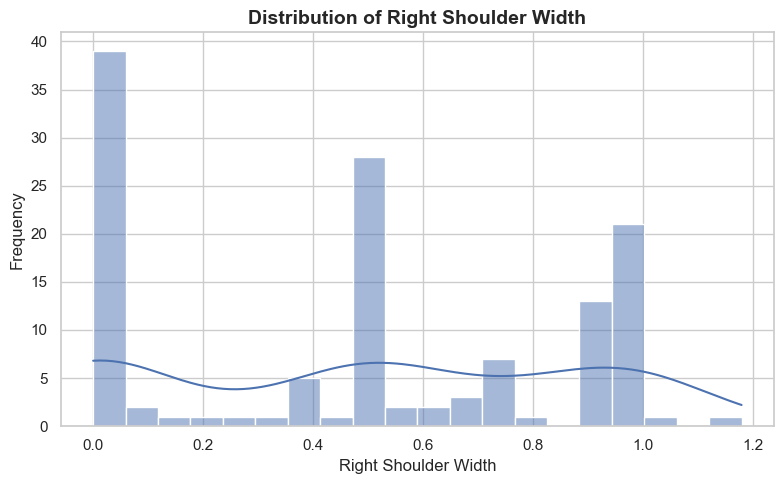

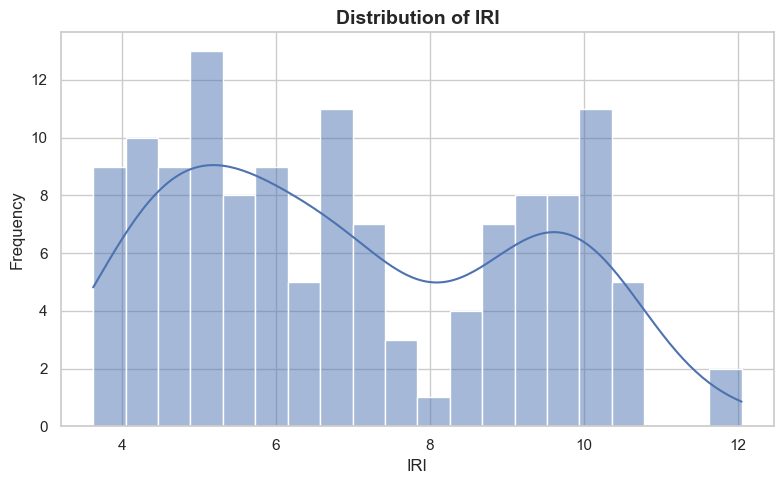

In [11]:
# ============================================================
# STEP 11: HISTOGRAMS + KDE
# ============================================================

plot_variables = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

for variable in plot_variables:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=variable,
        kde=True,
        bins=20
    )

    plt.title(
        f"Distribution of {variable}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(variable)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

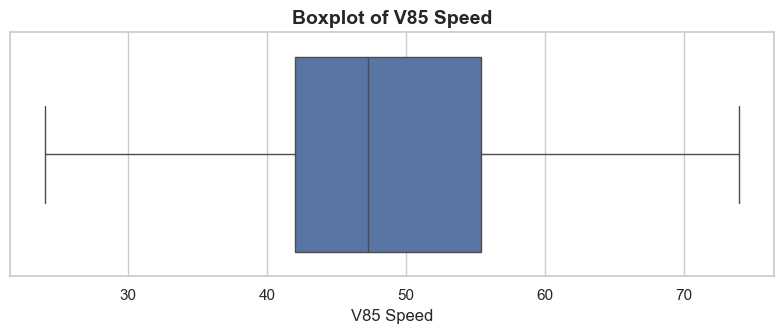

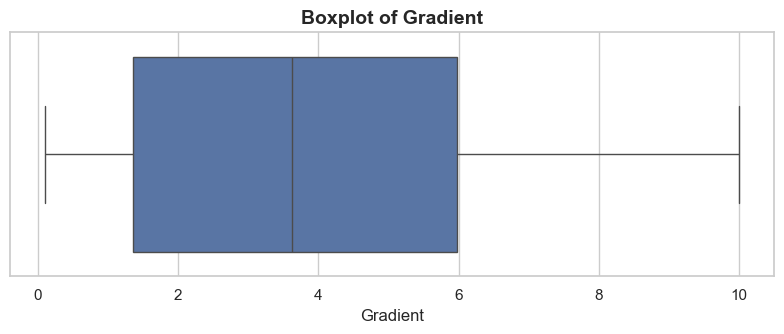

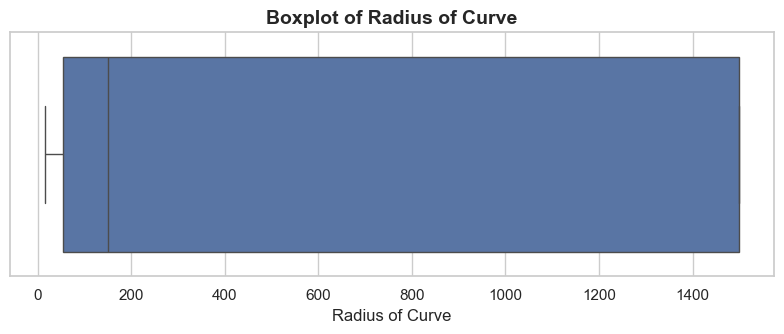

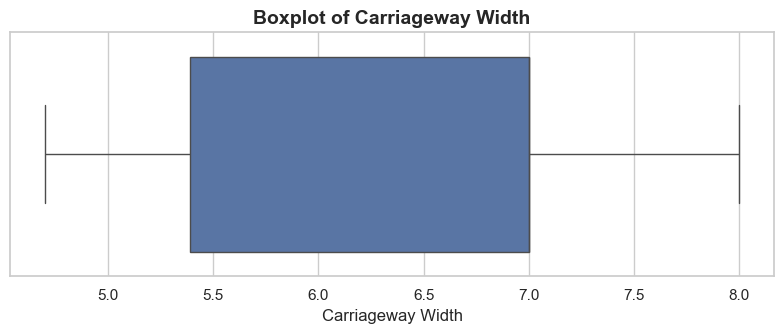

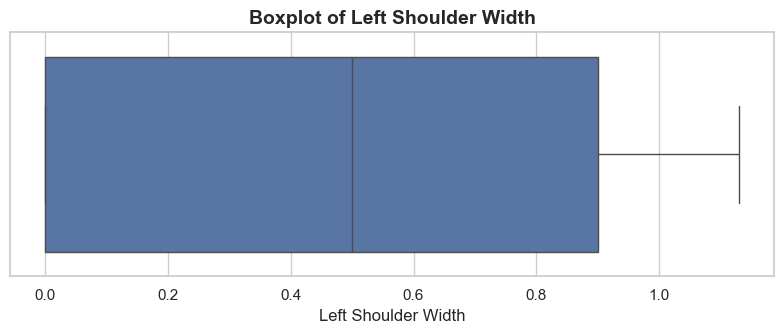

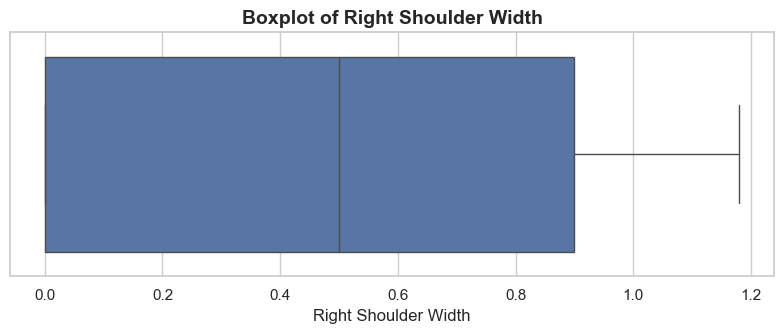

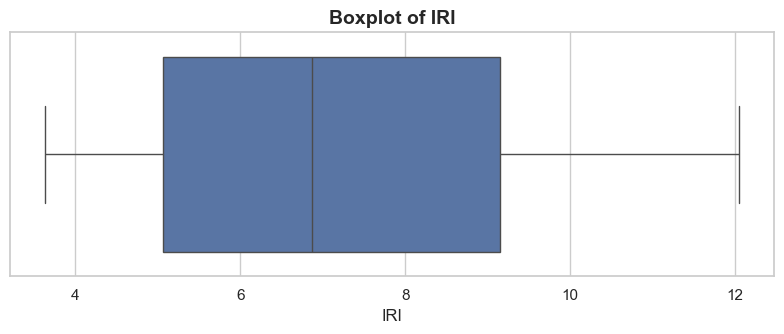

In [12]:
# ============================================================
# STEP 12: BOXPLOTS
# ============================================================

for variable in plot_variables:

    plt.figure(figsize=(8, 3.5))

    sns.boxplot(
        data=df,
        x=variable
    )

    plt.title(
        f"Boxplot of {variable}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(variable)

    plt.tight_layout()
    plt.show()

In [13]:
# ============================================================
# STEP 13: SHOULDER TYPE COUNTS
# ============================================================

print("Left Shoulder Type:")
display(
    df["Left Shoulder Type"]
    .value_counts()
    .to_frame("Count")
)

print("\nRight Shoulder Type:")
display(
    df["Right Shoulder Type"]
    .value_counts()
    .to_frame("Count")
)

Left Shoulder Type:


,Count
Left Shoulder Type,
Gravel,57
Absent,41
Paved,32



Right Shoulder Type:


,Count
Right Shoulder Type,
Gravel,49
Paved,42
Absent,39


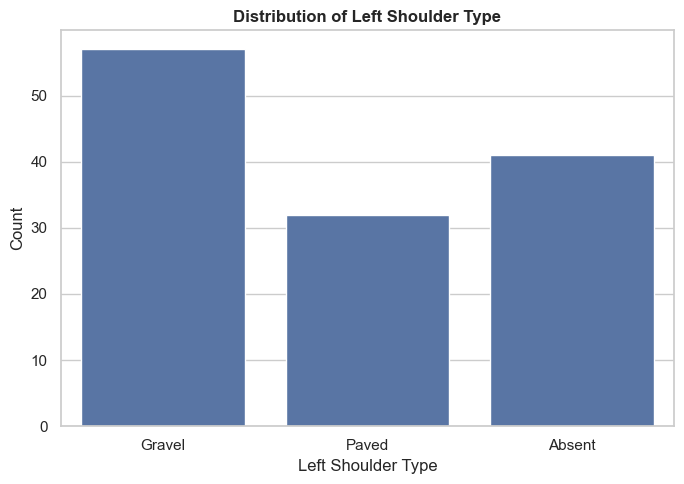

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Left Shoulder Type"
)

plt.title(
    "Distribution of Left Shoulder Type",
    fontweight="bold"
)

plt.xlabel("Left Shoulder Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

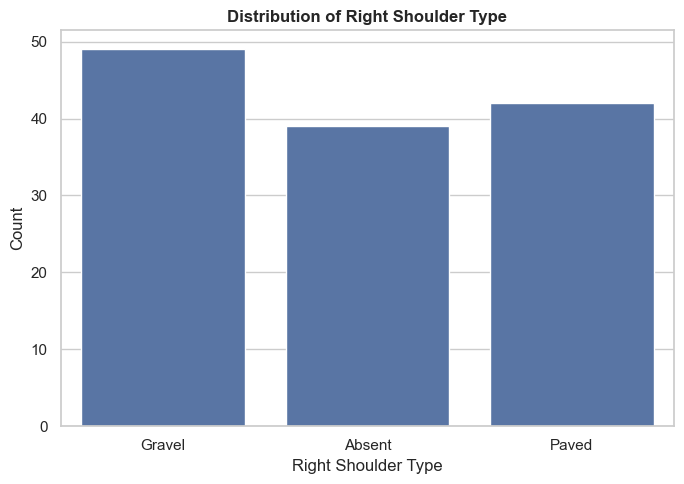

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Right Shoulder Type"
)

plt.title(
    "Distribution of Right Shoulder Type",
    fontweight="bold"
)

plt.xlabel("Right Shoulder Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

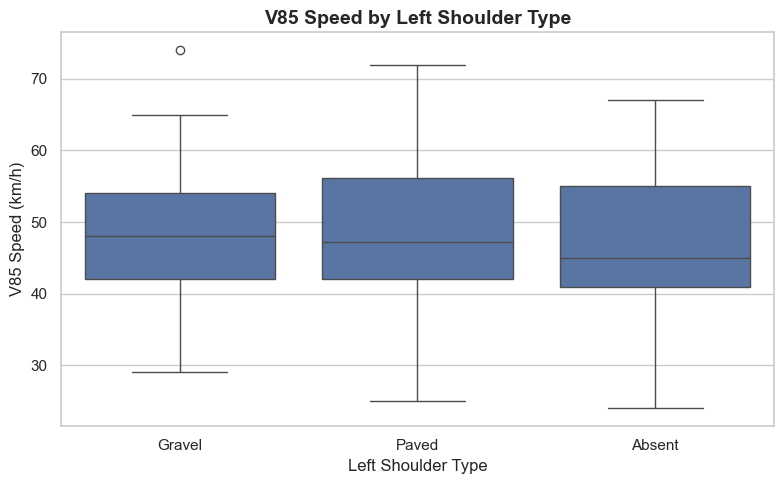

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Left Shoulder Type",
    y="V85 Speed"
)

plt.title(
    "V85 Speed by Left Shoulder Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Left Shoulder Type")
plt.ylabel("V85 Speed (km/h)")

plt.tight_layout()
plt.show()

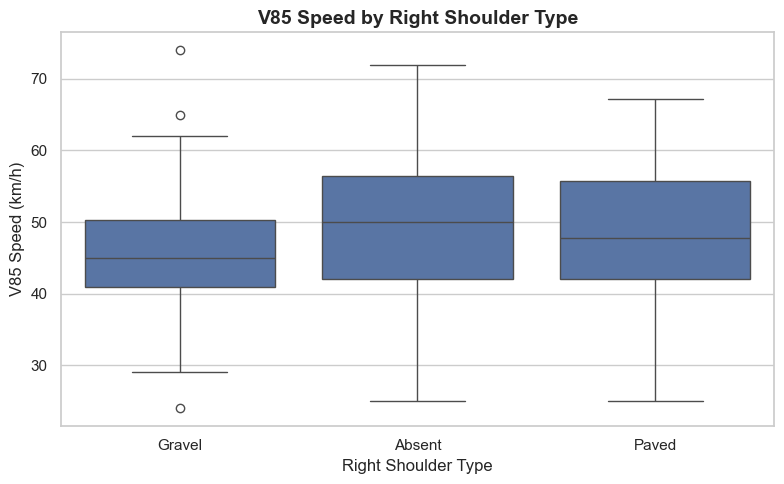

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Right Shoulder Type",
    y="V85 Speed"
)

plt.title(
    "V85 Speed by Right Shoulder Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Right Shoulder Type")
plt.ylabel("V85 Speed (km/h)")

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# STEP 16: PEARSON CORRELATION MATRIX
# ============================================================

correlation_variables = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

corr_matrix = df[correlation_variables].corr()

display(corr_matrix.round(3))

,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width,IRI
V85 Speed,1.000,-0.009,0.469,0.077,0.073,0.002,0.024
Gradient,-0.009,1.000,-0.150,-0.175,-0.211,-0.221,0.016
Radius of Curve,0.469,-0.150,1.000,0.039,0.213,0.070,-0.061
Carriageway Width,0.077,-0.175,0.039,1.000,0.019,-0.242,0.582
Left Shoulder Width,0.073,-0.211,0.213,0.019,1.000,0.247,-0.211
Right Shoulder Width,0.002,-0.221,0.070,-0.242,0.247,1.000,-0.207
IRI,0.024,0.016,-0.061,0.582,-0.211,-0.207,1.000


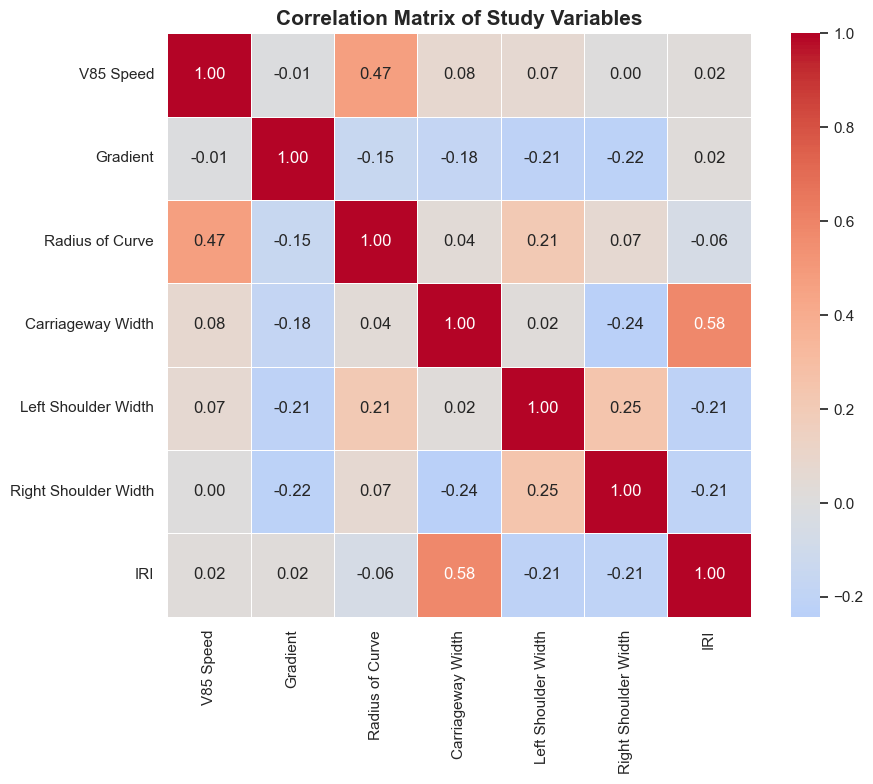

In [19]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Study Variables",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# CORRELATION WITH V85 SPEED
# ============================================================

v85_correlation = (
    corr_matrix["V85 Speed"]
    .drop("V85 Speed")
    .sort_values(ascending=False)
)

v85_corr_table = pd.DataFrame({
    "Variable": v85_correlation.index,
    "Correlation with V85": v85_correlation.values
})

display(v85_corr_table.round(3))

,Variable,Correlation with V85
0,Radius of Curve,0.469
1,Carriageway Width,0.077
2,Left Shoulder Width,0.073
3,IRI,0.024
4,Right Shoulder Width,0.002
5,Gradient,-0.009


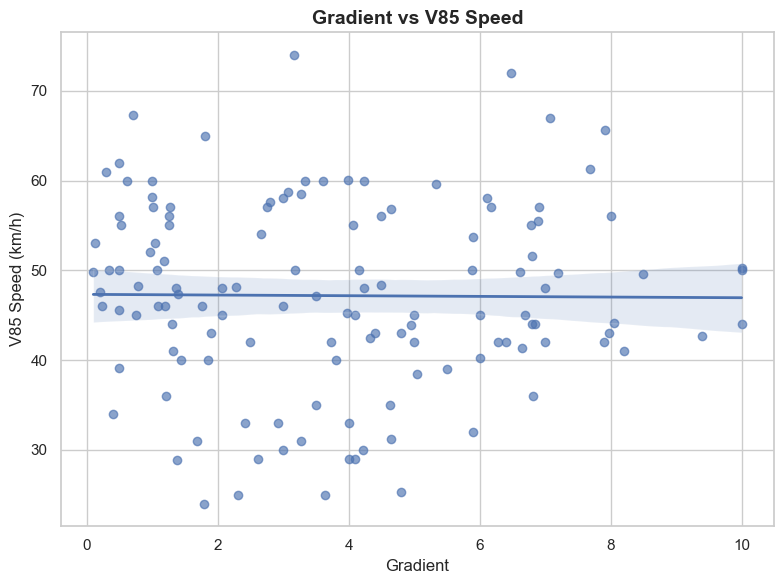

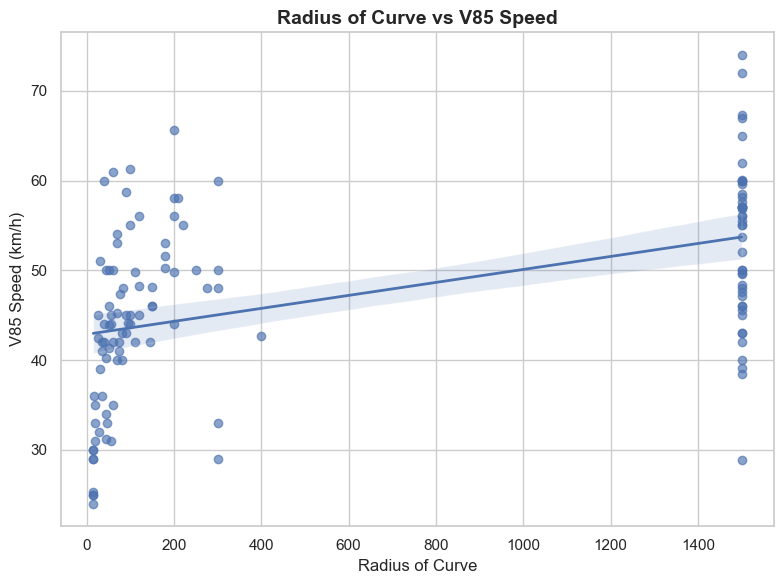

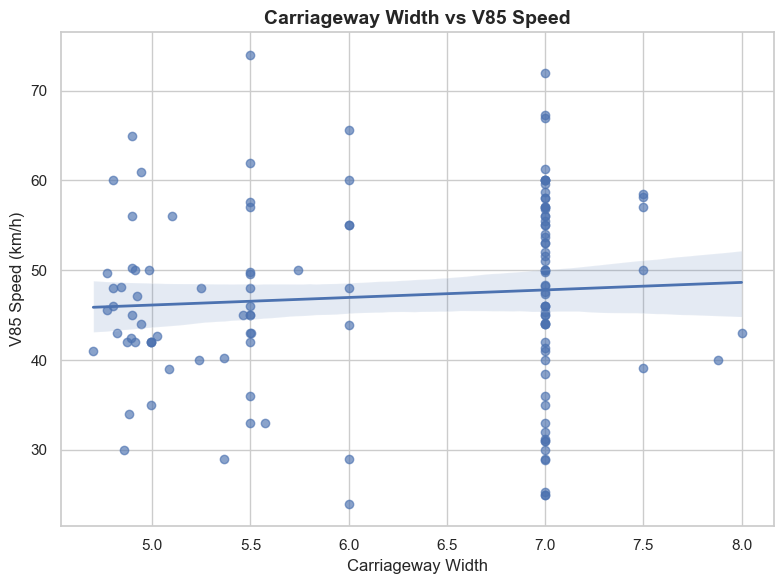

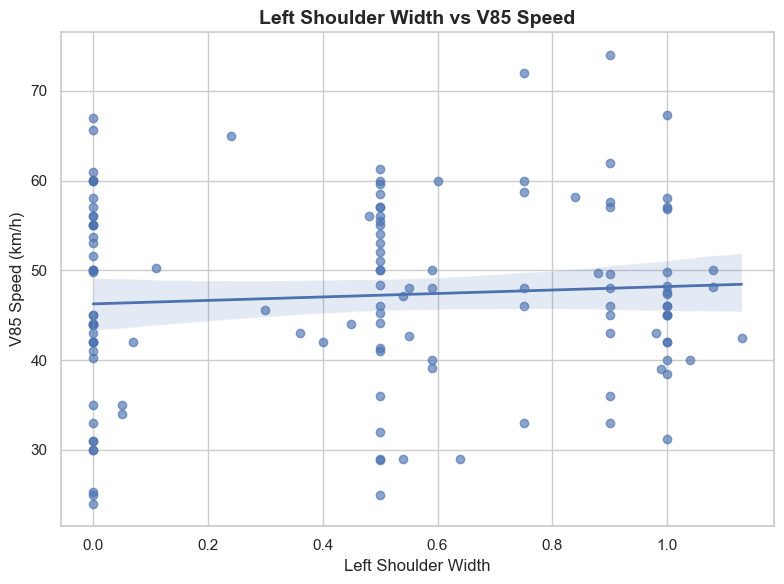

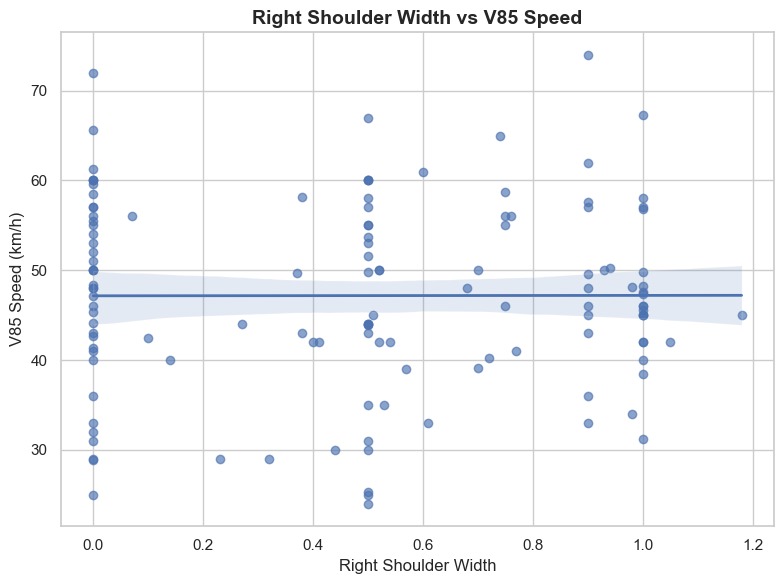

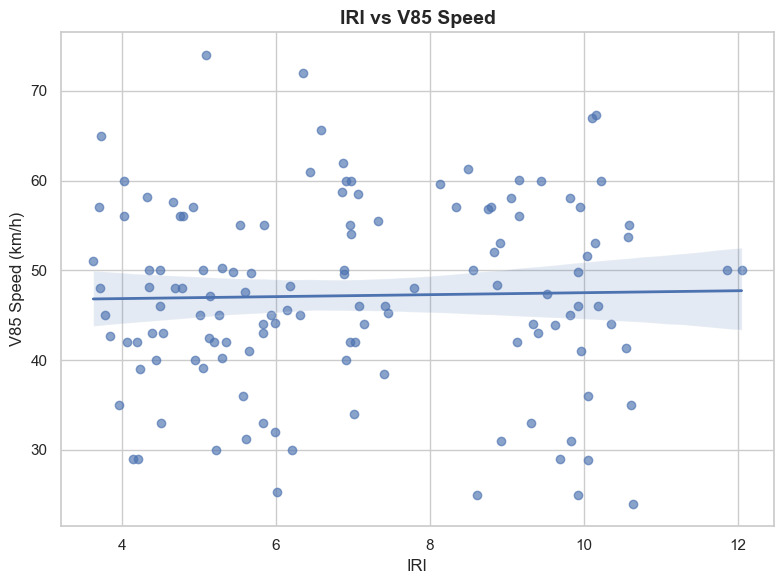

In [21]:
# ============================================================
# ALL ORIGINAL PREDICTORS VS V85
# ============================================================

relationship_variables = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "IRI"
]

for variable in relationship_variables:

    plt.figure(figsize=(8, 6))

    sns.regplot(
        data=df,
        x=variable,
        y="V85 Speed",
        scatter_kws={"alpha": 0.65},
        line_kws={"linewidth": 2}
    )

    plt.title(
        f"{variable} vs V85 Speed",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(variable)
    plt.ylabel("V85 Speed (km/h)")

    plt.tight_layout()
    plt.show()

In [22]:
# ============================================================
# STEP 26: INITIAL DATASET FOR VIF
# Includes shoulder type + separate shoulder widths
# ============================================================

vif_data_initial = df[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Left Shoulder Width",
        "Right Shoulder Width",
        "IRI",
        "Left Shoulder Type",
        "Right Shoulder Type"
    ]
].copy()

vif_data_initial = pd.get_dummies(
    vif_data_initial,
    columns=[
        "Left Shoulder Type",
        "Right Shoulder Type"
    ],
    drop_first=True,
    dtype=int
)

display(vif_data_initial.head())

print(vif_data_initial.columns.tolist())

,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width,IRI,Left Shoulder Type_Gravel,Left Shoulder Type_Paved,Right Shoulder Type_Gravel,Right Shoulder Type_Paved
0,1.27,1500.0,5.5,0.9,0.9,3.70,1,0,1,0
1,2.92,46.0,5.5,0.9,0.9,4.51,1,0,1,0
2,7.97,1500.0,5.5,0.9,0.9,4.39,1,0,1,0
3,2.07,1500.0,5.5,0.9,0.9,4.69,1,0,1,0
4,1.21,16.0,5.5,0.9,0.9,5.57,1,0,1,0


['Gradient', 'Radius of Curve', 'Carriageway Width', 'Left Shoulder Width', 'Right Shoulder Width', 'IRI', 'Left Shoulder Type_Gravel', 'Left Shoulder Type_Paved', 'Right Shoulder Type_Gravel', 'Right Shoulder Type_Paved']


In [23]:
# ============================================================
# STEP 27: INITIAL VIF CHECK
# ============================================================

X_vif_initial = vif_data_initial.astype(float)

X_vif_initial_const = sm.add_constant(
    X_vif_initial
)

vif_initial = pd.DataFrame()

vif_initial["Feature"] = (
    X_vif_initial_const.columns
)

vif_initial["VIF"] = [
    variance_inflation_factor(
        X_vif_initial_const.values,
        i
    )
    for i in range(X_vif_initial_const.shape[1])
]

display(vif_initial.round(3))

,Feature,VIF
0,const,92.656
1,Gradient,1.216
2,Radius of Curve,1.092
3,Carriageway Width,1.834
4,Left Shoulder Width,4.664
5,Right Shoulder Width,4.413
6,IRI,1.805
7,Left Shoulder Type_Gravel,6.230
8,Left Shoulder Type_Paved,4.982
9,Right Shoulder Type_Gravel,5.234


In [24]:
vif_initial_sorted = (
    vif_initial[
        vif_initial["Feature"] != "const"
    ]
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

display(vif_initial_sorted.round(3))

,Feature,VIF
0,Left Shoulder Type_Gravel,6.230
1,Right Shoulder Type_Paved,5.714
2,Right Shoulder Type_Gravel,5.234
3,Left Shoulder Type_Paved,4.982
4,Left Shoulder Width,4.664
5,Right Shoulder Width,4.413
6,Carriageway Width,1.834
7,IRI,1.805
8,Gradient,1.216
9,Radius of Curve,1.092


In [25]:
# ============================================================
# SHOULDER VARIABLE CORRELATION
# ============================================================

shoulder_columns = [
    col
    for col in vif_data_initial.columns
    if "Shoulder" in col
]

shoulder_corr = (
    vif_data_initial[shoulder_columns]
    .corr()
)

display(shoulder_corr.round(3))

,Left Shoulder Width,Right Shoulder Width,Left Shoulder Type_Gravel,Left Shoulder Type_Paved,Right Shoulder Type_Gravel,Right Shoulder Type_Paved
Left Shoulder Width,1.000,0.247,0.516,0.295,0.284,-0.309
Right Shoulder Width,0.247,1.000,0.123,-0.206,0.446,0.347
Left Shoulder Type_Gravel,0.516,0.123,1.000,-0.505,0.400,-0.412
Left Shoulder Type_Paved,0.295,-0.206,-0.505,1.000,-0.223,-0.089
Right Shoulder Type_Gravel,0.284,0.446,0.400,-0.223,1.000,-0.537
Right Shoulder Type_Paved,-0.309,0.347,-0.412,-0.089,-0.537,1.000


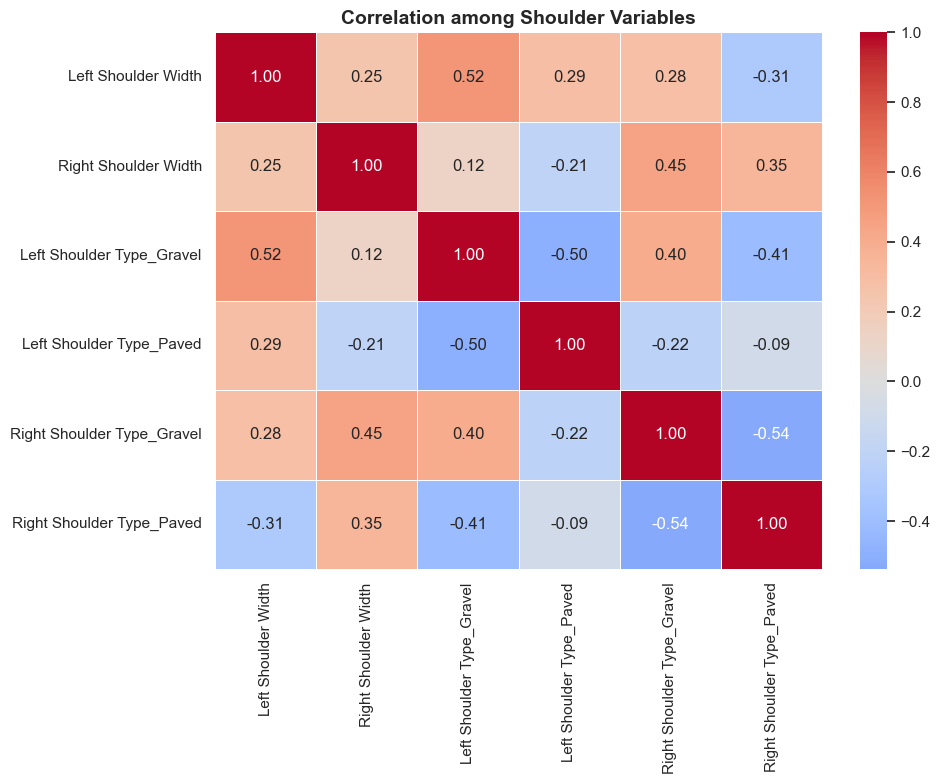

In [26]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    shoulder_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation among Shoulder Variables",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# STEP 29: CREATE AVERAGE SHOULDER WIDTH
# ============================================================

df["Average Shoulder Width"] = (
    df["Left Shoulder Width"]
    + df["Right Shoulder Width"]
) / 2

display(
    df[
        [
            "Left Shoulder Width",
            "Right Shoulder Width",
            "Average Shoulder Width"
        ]
    ].head(10)
)

,Left Shoulder Width,Right Shoulder Width,Average Shoulder Width
0,0.9,0.9,0.9
1,0.9,0.9,0.9
2,0.9,0.9,0.9
3,0.9,0.9,0.9
4,0.9,0.9,0.9
5,0.9,0.9,0.9
6,0.9,0.9,0.9
7,0.9,0.9,0.9
8,0.9,0.9,0.9
9,0.9,0.9,0.9


In [28]:
print(
    df["Average Shoulder Width"]
    .describe()
)

count    130.000000
mean       0.479500
std        0.307118
min        0.000000
25%        0.250000
50%        0.297500
75%        0.750000
max        1.030000
Name: Average Shoulder Width, dtype: float64


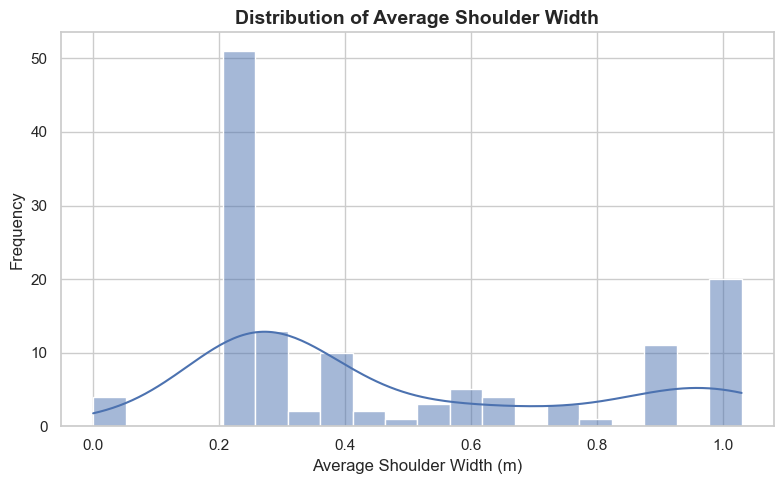

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Average Shoulder Width",
    kde=True,
    bins=20
)

plt.title(
    "Distribution of Average Shoulder Width",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average Shoulder Width (m)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

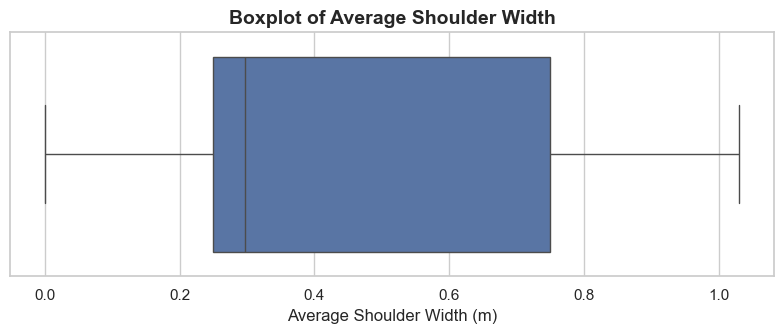

In [30]:
plt.figure(figsize=(8, 3.5))

sns.boxplot(
    data=df,
    x="Average Shoulder Width"
)

plt.title(
    "Boxplot of Average Shoulder Width",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average Shoulder Width (m)")

plt.tight_layout()
plt.show()

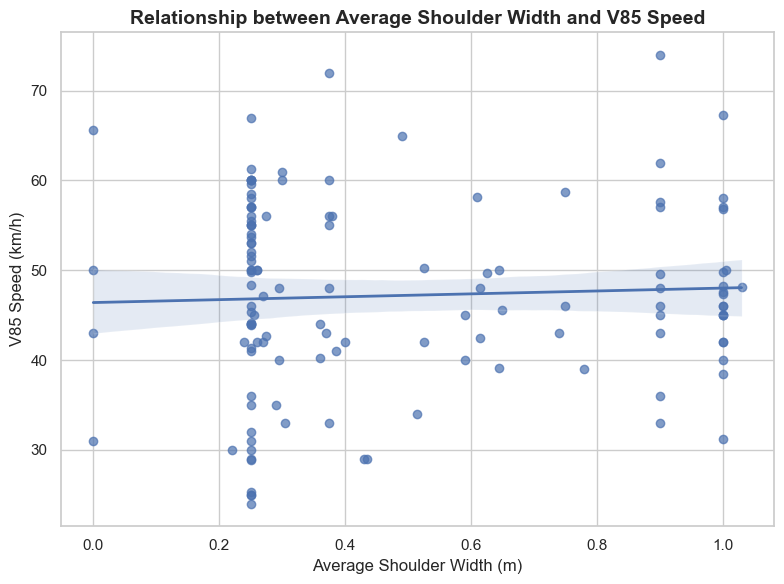

In [31]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="Average Shoulder Width",
    y="V85 Speed",
    scatter_kws={"alpha": 0.7},
    line_kws={"linewidth": 2}
)

plt.title(
    "Relationship between Average Shoulder Width and V85 Speed",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Average Shoulder Width (m)")
plt.ylabel("V85 Speed (km/h)")

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# STEP 33: FINAL MODEL CORRELATION MATRIX
# ============================================================

final_corr_variables = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width",
    "IRI"
]

final_corr = (
    df[final_corr_variables]
    .corr()
)

display(final_corr.round(3))

,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Average Shoulder Width,IRI
V85 Speed,1.000,-0.009,0.469,0.077,0.048,0.024
Gradient,-0.009,1.000,-0.150,-0.175,-0.274,0.016
Radius of Curve,0.469,-0.150,1.000,0.039,0.180,-0.061
Carriageway Width,0.077,-0.175,0.039,1.000,-0.139,0.582
Average Shoulder Width,0.048,-0.274,0.180,-0.139,1.000,-0.264
IRI,0.024,0.016,-0.061,0.582,-0.264,1.000


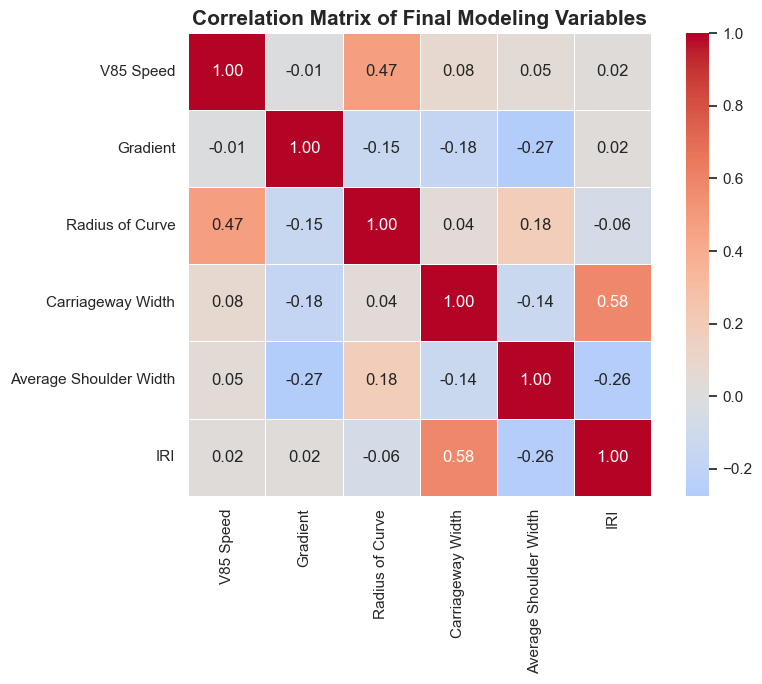

In [33]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    final_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Final Modeling Variables",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [34]:
final_v85_corr = (
    final_corr["V85 Speed"]
    .drop("V85 Speed")
    .sort_values(ascending=False)
)

final_v85_corr_table = pd.DataFrame({
    "Variable": final_v85_corr.index,
    "Pearson Correlation with V85": final_v85_corr.values
})

display(final_v85_corr_table.round(3))

,Variable,Pearson Correlation with V85
0,Radius of Curve,0.469
1,Carriageway Width,0.077
2,Average Shoulder Width,0.048
3,IRI,0.024
4,Gradient,-0.009


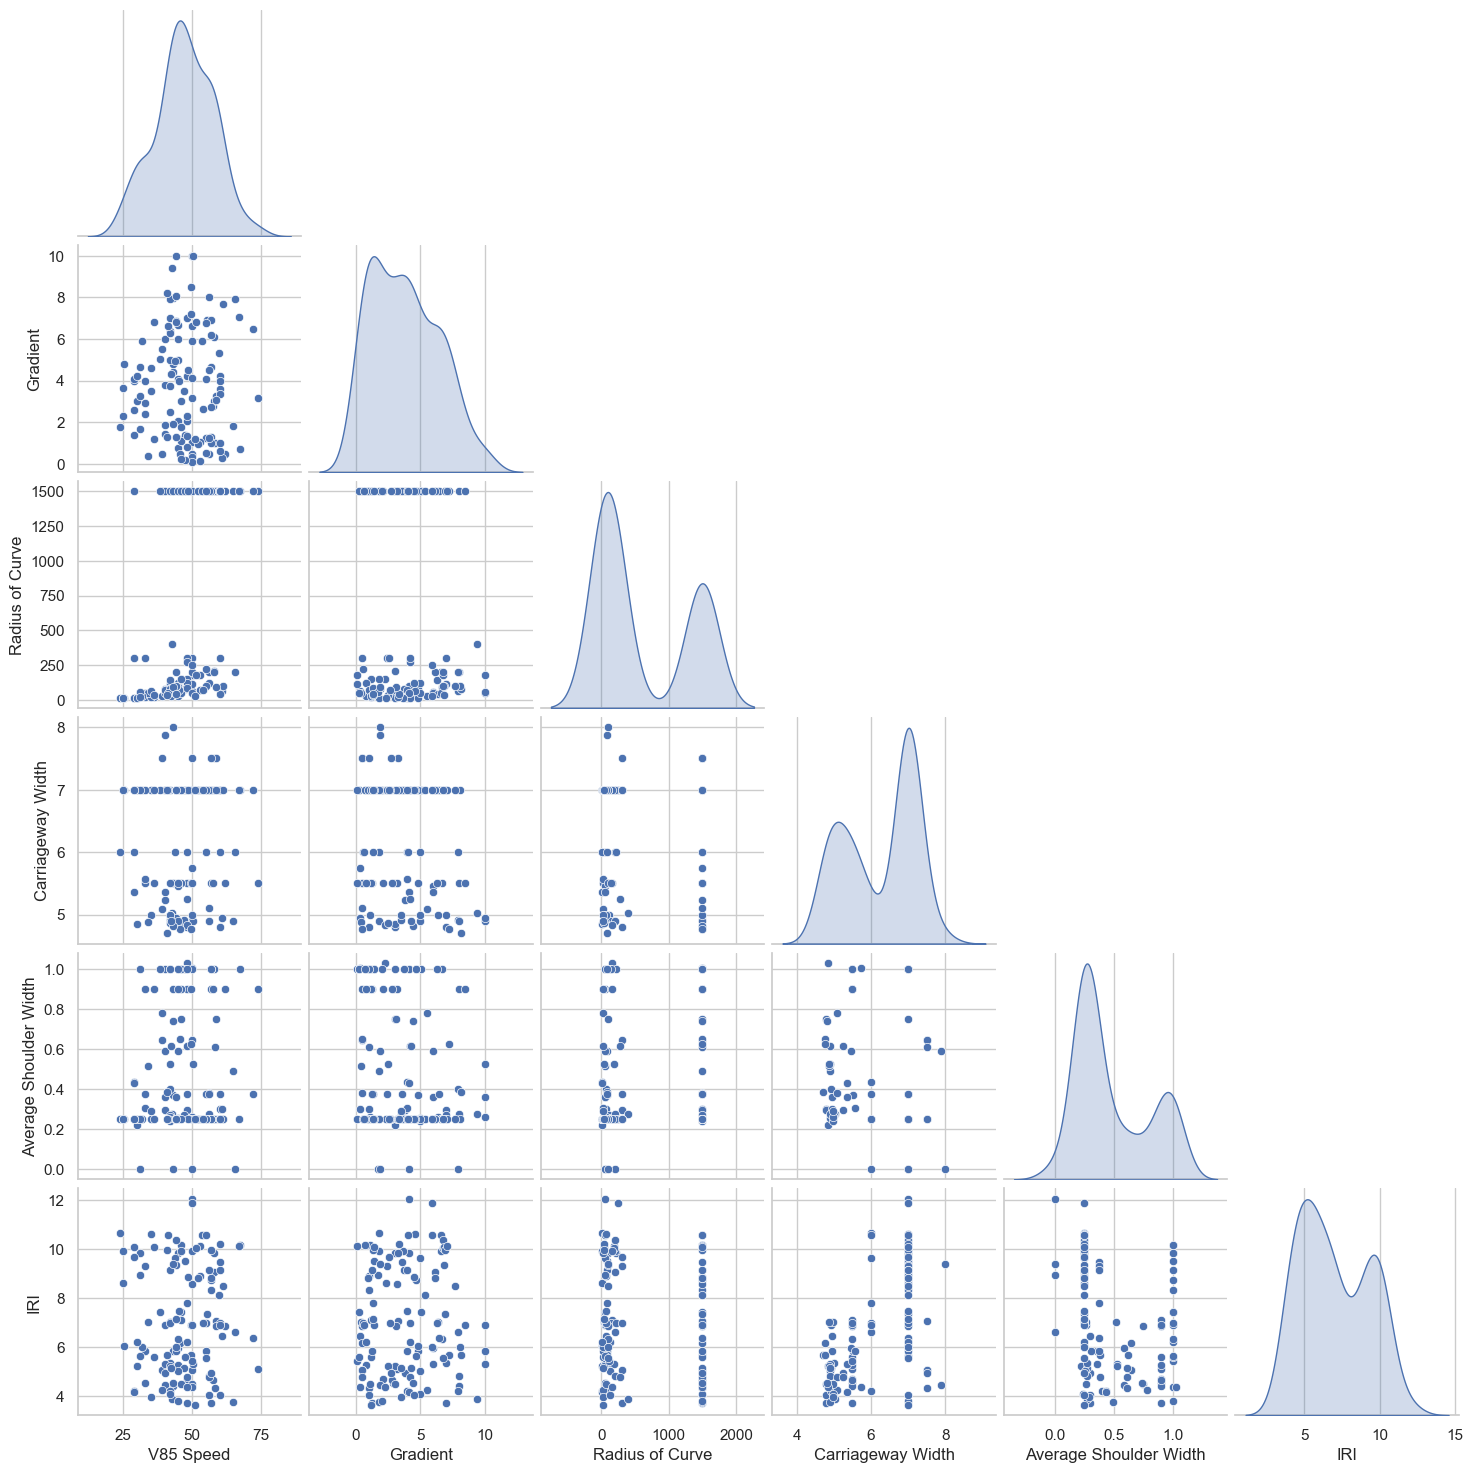

In [35]:
# ============================================================
# STEP 35: PAIRWISE RELATIONSHIP PLOT
# ============================================================

sns.pairplot(
    df[final_corr_variables],
    diag_kind="kde",
    corner=True
)

plt.show()

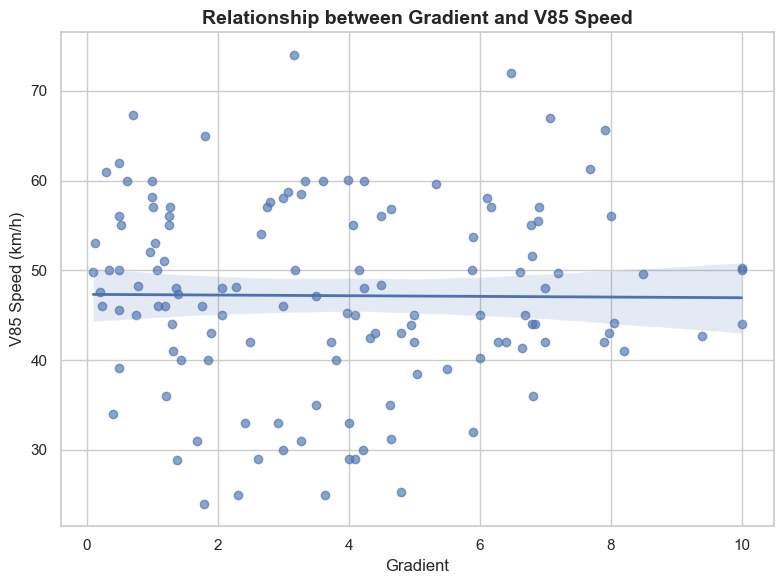

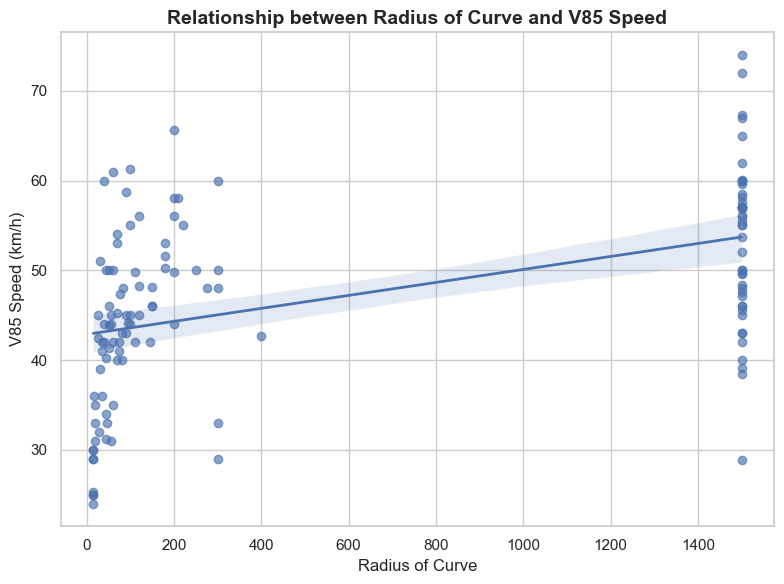

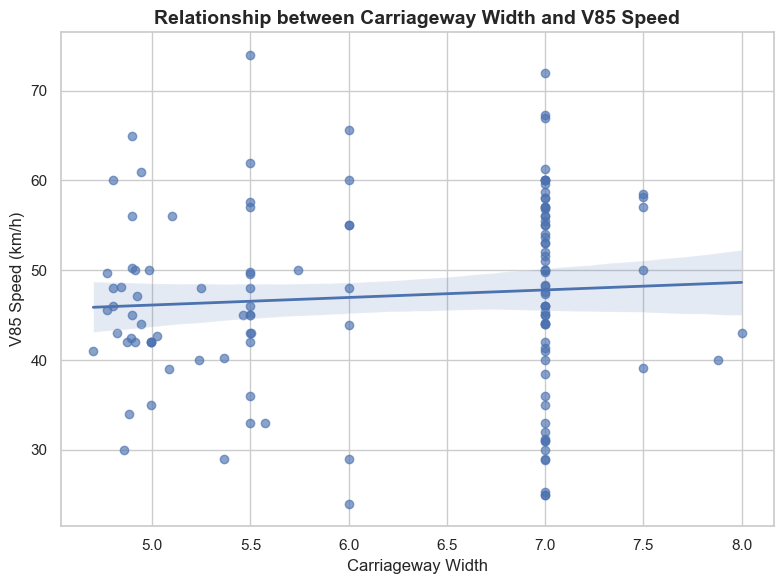

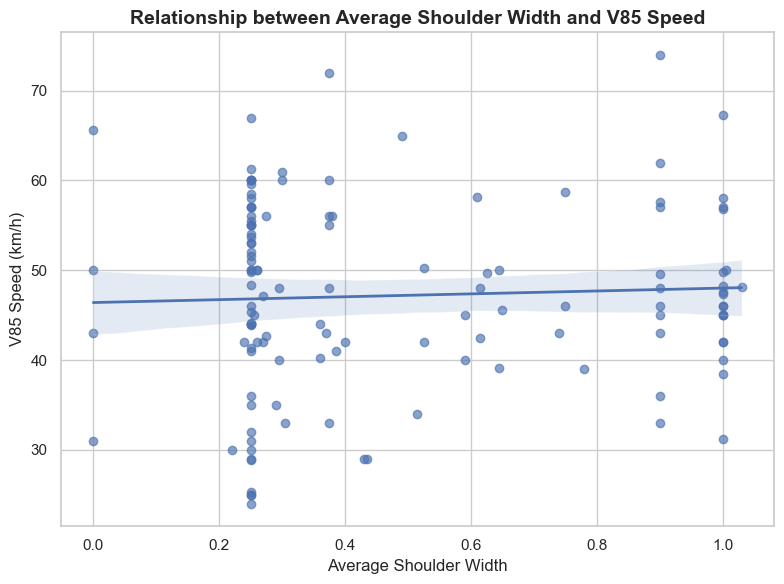

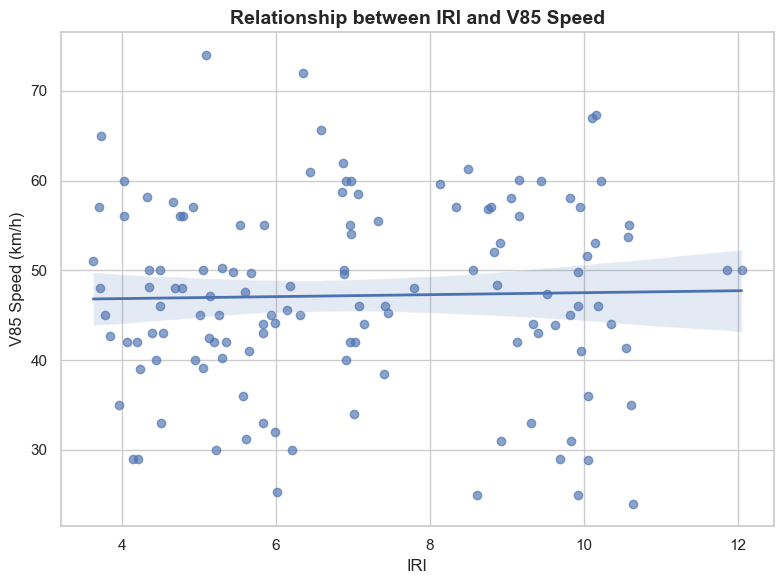

In [36]:
# ============================================================
# FINAL PREDICTORS VS V85
# ============================================================

final_predictors = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width",
    "IRI"
]

for variable in final_predictors:

    plt.figure(figsize=(8, 6))

    sns.regplot(
        data=df,
        x=variable,
        y="V85 Speed",
        scatter_kws={"alpha": 0.65},
        line_kws={"linewidth": 2}
    )

    plt.title(
        f"Relationship between {variable} and V85 Speed",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(variable)
    plt.ylabel("V85 Speed (km/h)")

    plt.tight_layout()
    plt.show()

In [37]:
# ============================================================
# STEP 37: FINAL FEATURE SET
# ============================================================

final_features = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width",
    "IRI"
]

X = df[final_features].copy()

y = df["V85 Speed"].copy()

print("Final predictors:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

Final predictors:
['Gradient', 'Radius of Curve', 'Carriageway Width', 'Average Shoulder Width', 'IRI']

X shape: (130, 5)
y shape: (130,)


,Gradient,Radius of Curve,Carriageway Width,Average Shoulder Width,IRI
0,1.27,1500.0,5.5,0.9,3.70
1,2.92,46.0,5.5,0.9,4.51
2,7.97,1500.0,5.5,0.9,4.39
3,2.07,1500.0,5.5,0.9,4.69
4,1.21,16.0,5.5,0.9,5.57


In [38]:
# ============================================================
# STEP 38: FINAL VIF CHECK
# ============================================================

X_vif_final = X.astype(float)

X_vif_final_const = sm.add_constant(
    X_vif_final
)

vif_final = pd.DataFrame()

vif_final["Feature"] = (
    X_vif_final_const.columns
)

vif_final["VIF"] = [
    variance_inflation_factor(
        X_vif_final_const.values,
        i
    )
    for i in range(X_vif_final_const.shape[1])
]

display(vif_final.round(3))

,Feature,VIF
0,const,64.700
1,Gradient,1.156
2,Radius of Curve,1.051
3,Carriageway Width,1.604
4,Average Shoulder Width,1.192
5,IRI,1.610


In [39]:
final_vif_table = (
    vif_final[
        vif_final["Feature"] != "const"
    ]
    .sort_values(
        by="VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

display(final_vif_table.round(3))

,Feature,VIF
0,IRI,1.610
1,Carriageway Width,1.604
2,Average Shoulder Width,1.192
3,Gradient,1.156
4,Radius of Curve,1.051


In [40]:
# ============================================================
# STEP 39: INITIAL VS FINAL VIF
# ============================================================

print("=" * 75)
print("INITIAL VIF")
print("Separate Shoulder Widths + Shoulder Types + IRI")
print("=" * 75)

display(vif_initial_sorted.round(3))


print("\n" + "=" * 75)
print("FINAL VIF")
print("Average Shoulder Width + No Shoulder Type + IRI")
print("=" * 75)

display(final_vif_table.round(3))

INITIAL VIF
Separate Shoulder Widths + Shoulder Types + IRI


,Feature,VIF
0,Left Shoulder Type_Gravel,6.230
1,Right Shoulder Type_Paved,5.714
2,Right Shoulder Type_Gravel,5.234
3,Left Shoulder Type_Paved,4.982
4,Left Shoulder Width,4.664
5,Right Shoulder Width,4.413
6,Carriageway Width,1.834
7,IRI,1.805
8,Gradient,1.216
9,Radius of Curve,1.092



FINAL VIF
Average Shoulder Width + No Shoulder Type + IRI


,Feature,VIF
0,IRI,1.610
1,Carriageway Width,1.604
2,Average Shoulder Width,1.192
3,Gradient,1.156
4,Radius of Curve,1.051


In [41]:
# ============================================================
# MODEL DEVELOPMENT
# STEP 1: IMPORT MODELING LIBRARIES
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

print("Modeling libraries imported successfully.")

Modeling libraries imported successfully.


In [42]:
# ============================================================
# STEP 2: DEFINE FINAL PREDICTORS AND TARGET
# ============================================================

final_features = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width",
    "IRI"
]

X = df[final_features].copy()

y = df["V85 Speed"].copy()

print("Independent Variables:")
print(X.columns.tolist())

print("\nDependent Variable:")
print(y.name)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

display(X.head())

Independent Variables:
['Gradient', 'Radius of Curve', 'Carriageway Width', 'Average Shoulder Width', 'IRI']

Dependent Variable:
V85 Speed

Shape of X: (130, 5)
Shape of y: (130,)


,Gradient,Radius of Curve,Carriageway Width,Average Shoulder Width,IRI
0,1.27,1500.0,5.5,0.9,3.70
1,2.92,46.0,5.5,0.9,4.51
2,7.97,1500.0,5.5,0.9,4.39
3,2.07,1500.0,5.5,0.9,4.69
4,1.21,16.0,5.5,0.9,5.57


In [43]:
# ============================================================
# STEP 3: FINAL DATA QUALITY CHECK
# ============================================================

print("Missing values in predictors:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

print("\nTotal missing values in X:",
      X.isnull().sum().sum())

print("Total missing values in y:",
      y.isnull().sum())

Missing values in predictors:
Gradient                  0
Radius of Curve           0
Carriageway Width         0
Average Shoulder Width    0
IRI                       0
dtype: int64

Missing values in target:
0

Total missing values in X: 0
Total missing values in y: 0


In [44]:
test_size = 0.20
random_state = 42

In [45]:
# ============================================================
# STEP 4: TRAIN-TEST SPLIT
# 80% Training / 20% Testing
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("TRAIN-TEST SPLIT COMPLETED")
print("=" * 50)

print("Total observations :", len(X))
print("Training observations:", len(X_train))
print("Testing observations :", len(X_test))

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

TRAIN-TEST SPLIT COMPLETED
Total observations : 130
Training observations: 104
Testing observations : 26

X_train shape: (104, 5)
X_test shape : (26, 5)
y_train shape: (104,)
y_test shape : (26,)


In [46]:
# ============================================================
# STEP 5: CHECK TRAIN AND TEST TARGET DISTRIBUTION
# ============================================================

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "N": [len(y_train), len(y_test)],
    "Mean V85": [y_train.mean(), y_test.mean()],
    "Std V85": [y_train.std(), y_test.std()],
    "Min V85": [y_train.min(), y_test.min()],
    "Max V85": [y_train.max(), y_test.max()]
})

display(split_summary.round(2))

,Dataset,N,Mean V85,Std V85,Min V85,Max V85
0,Training,104,47.44,10.59,24.0,74.0
1,Testing,26,46.15,9.73,25.0,60.0


In [47]:
# ============================================================
# STEP 6: FEATURE STANDARDIZATION
# ============================================================

scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to testing data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [48]:
# ============================================================
# STEP 7: CONVERT SCALED DATA BACK TO DATAFRAME
# ============================================================

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=final_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=final_features,
    index=X_test.index
)

display(X_train_scaled.head())

,Gradient,Radius of Curve,Carriageway Width,Average Shoulder Width,IRI
70,-0.022320,-0.815829,0.821458,1.732898,1.022259
78,1.075678,-0.852662,0.821458,-0.757494,1.665850
47,-0.485625,-0.874762,-1.404032,0.155650,-0.758948
0,-0.948931,1.283668,-0.745788,1.400846,-1.438797
12,-1.238968,1.283668,1.343873,0.554112,-0.826933


In [49]:
# ============================================================
# VERIFY STANDARDIZATION
# ============================================================

scaling_check = pd.DataFrame({
    "Mean": X_train_scaled.mean(),
    "Standard Deviation": X_train_scaled.std(ddof=0)
})

display(scaling_check.round(3))

,Mean,Standard Deviation
Gradient,-0.0,1.0
Radius of Curve,-0.0,1.0
Carriageway Width,-0.0,1.0
Average Shoulder Width,-0.0,1.0
IRI,0.0,1.0


In [50]:
# ============================================================
# MODEL 1: MULTIPLE LINEAR REGRESSION
# ============================================================

mlr_model = LinearRegression()

mlr_model.fit(
    X_train_scaled,
    y_train
)

print("Multiple Linear Regression model trained successfully.")

Multiple Linear Regression model trained successfully.


In [51]:
# ============================================================
# MLR PREDICTIONS
# ============================================================

y_train_pred_mlr = mlr_model.predict(
    X_train_scaled
)

y_test_pred_mlr = mlr_model.predict(
    X_test_scaled
)

In [52]:
# ============================================================
# MLR — TRAINING PERFORMANCE
# ============================================================

mlr_train_r2 = r2_score(
    y_train,
    y_train_pred_mlr
)

mlr_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_mlr
    )
)

mlr_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_mlr
)

print("MLR TRAINING PERFORMANCE")
print("=" * 45)

print(f"R²   : {mlr_train_r2:.4f}")
print(f"RMSE : {mlr_train_rmse:.4f} km/h")
print(f"MAE  : {mlr_train_mae:.4f} km/h")

MLR TRAINING PERFORMANCE
R²   : 0.2515
RMSE : 9.1179 km/h
MAE  : 7.2462 km/h


In [53]:
# ============================================================
# MLR — TEST PERFORMANCE
# ============================================================

mlr_test_r2 = r2_score(
    y_test,
    y_test_pred_mlr
)

mlr_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_mlr
    )
)

mlr_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_mlr
)

print("MLR TEST PERFORMANCE")
print("=" * 45)

print(f"R²   : {mlr_test_r2:.4f}")
print(f"RMSE : {mlr_test_rmse:.4f} km/h")
print(f"MAE  : {mlr_test_mae:.4f} km/h")

MLR TEST PERFORMANCE
R²   : 0.0688
RMSE : 9.2035 km/h
MAE  : 7.4288 km/h


In [54]:
# ============================================================
# MLR PERFORMANCE SUMMARY
# ============================================================

mlr_performance = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],

    "R²": [
        mlr_train_r2,
        mlr_test_r2
    ],

    "RMSE (km/h)": [
        mlr_train_rmse,
        mlr_test_rmse
    ],

    "MAE (km/h)": [
        mlr_train_mae,
        mlr_test_mae
    ]
})

display(
    mlr_performance.round(3)
)

,Dataset,R²,RMSE (km/h),MAE (km/h)
0,Training,0.252,9.118,7.246
1,Testing,0.069,9.204,7.429


In [55]:
# ============================================================
# MLR COEFFICIENTS
# ============================================================

mlr_coefficients = pd.DataFrame({
    "Variable": final_features,
    "Coefficient": mlr_model.coef_
})

mlr_coefficients["Absolute Coefficient"] = (
    mlr_coefficients["Coefficient"].abs()
)

mlr_coefficients = (
    mlr_coefficients
    .sort_values(
        "Absolute Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    mlr_coefficients.round(4)
)

,Variable,Coefficient,Absolute Coefficient
0,Radius of Curve,5.2932,5.2932
1,Gradient,1.0047,1.0047
2,Carriageway Width,0.5044,0.5044
3,IRI,-0.4619,0.4619
4,Average Shoulder Width,0.0714,0.0714


In [56]:
print(
    f"MLR Intercept: {mlr_model.intercept_:.4f}"
)

MLR Intercept: 47.4361


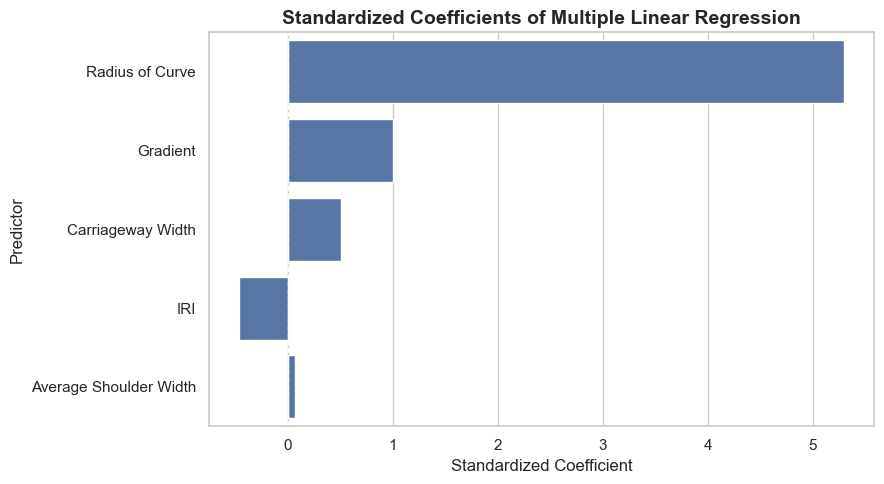

In [57]:
# ============================================================
# MLR COEFFICIENT PLOT
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=mlr_coefficients,
    x="Coefficient",
    y="Variable"
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Standardized Coefficients of Multiple Linear Regression",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Standardized Coefficient")
plt.ylabel("Predictor")

plt.tight_layout()
plt.show()

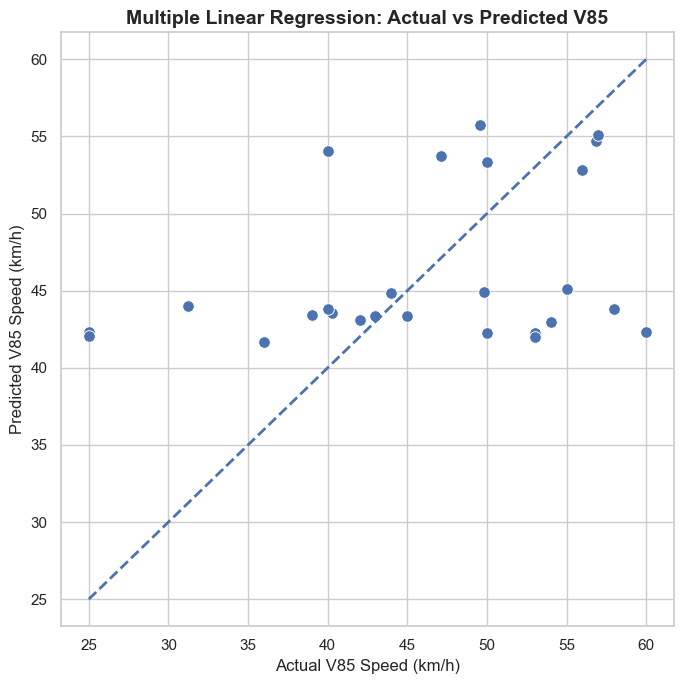

In [58]:
# ============================================================
# MLR: ACTUAL VS PREDICTED
# TEST DATA
# ============================================================

plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_mlr,
    s=70
)

# Perfect prediction line
min_value = min(
    y_test.min(),
    y_test_pred_mlr.min()
)

max_value = max(
    y_test.max(),
    y_test_pred_mlr.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "--",
    linewidth=2
)

plt.xlabel(
    "Actual V85 Speed (km/h)"
)

plt.ylabel(
    "Predicted V85 Speed (km/h)"
)

plt.title(
    "Multiple Linear Regression: Actual vs Predicted V85",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# MLR RESIDUALS
# ============================================================

mlr_residuals = (
    y_test.values
    - y_test_pred_mlr
)

print("Mean test residual:",
      np.mean(mlr_residuals))

Mean test residual: -0.034443465471289375


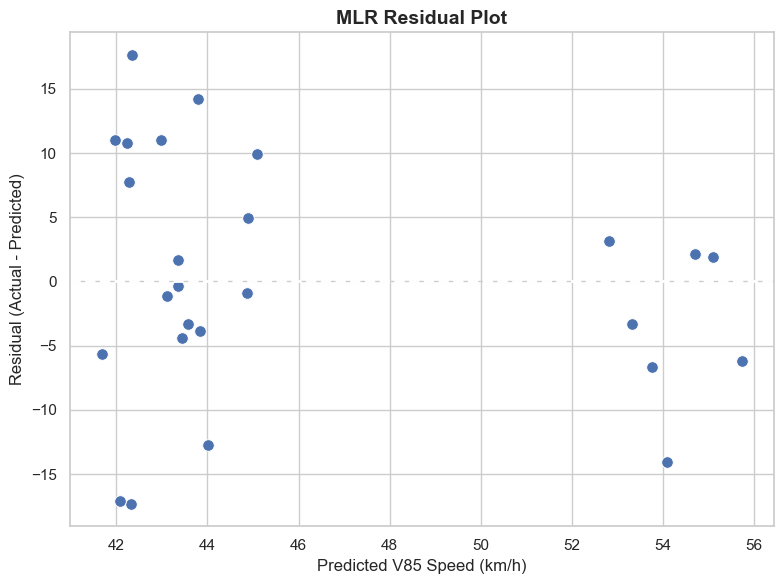

In [60]:
# ============================================================
# MLR: RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test_pred_mlr,
    y=mlr_residuals,
    s=70
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Predicted V85 Speed (km/h)"
)

plt.ylabel(
    "Residual (Actual - Predicted)"
)

plt.title(
    "MLR Residual Plot",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

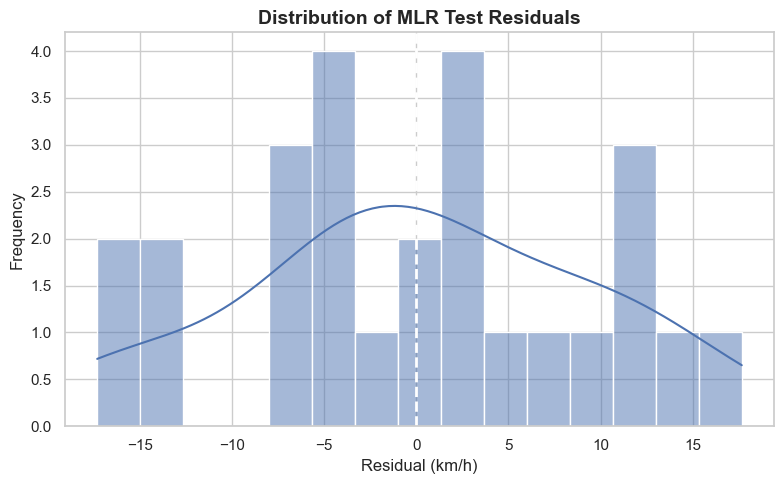

In [61]:
# ============================================================
# DISTRIBUTION OF MLR RESIDUALS
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    mlr_residuals,
    kde=True,
    bins=15
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual (km/h)")
plt.ylabel("Frequency")

plt.title(
    "Distribution of MLR Test Residuals",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [62]:
# ============================================================
# MLR ACTUAL VS PREDICTED TABLE
# ============================================================

mlr_predictions = pd.DataFrame({
    "Actual V85": y_test.values,
    "Predicted V85": y_test_pred_mlr,
    "Residual": mlr_residuals,
    "Absolute Error": np.abs(mlr_residuals)
})

display(
    mlr_predictions.round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
0,58.00,43.79,14.21,14.21
1,56.00,52.82,3.18,3.18
2,40.00,54.08,-14.08,14.08
3,40.25,43.57,-3.32,3.32
4,60.00,42.33,17.67,17.67
5,45.00,43.35,1.65,1.65
6,56.85,54.70,2.15,2.15
7,44.00,44.86,-0.86,0.86
8,49.80,44.88,4.92,4.92
9,39.00,43.44,-4.44,4.44


In [63]:
# ============================================================
# MODEL 2: BASE RANDOM FOREST REGRESSION
# ============================================================

from sklearn.ensemble import RandomForestRegressor

In [64]:
# ============================================================
# BASE RANDOM FOREST MODEL TRAINING
# ============================================================

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

print("Base Random Forest model trained successfully.")

Base Random Forest model trained successfully.


In [65]:
# ============================================================
# RANDOM FOREST PREDICTIONS
# ============================================================

y_train_pred_rf = rf.predict(X_train)

y_test_pred_rf = rf.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [66]:
# ============================================================
# RANDOM FOREST MODEL EVALUATION
# ============================================================

# -----------------------
# Training Performance
# -----------------------

rf_train_r2 = r2_score(
    y_train,
    y_train_pred_rf
)

rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_rf
    )
)

rf_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_rf
)


# -----------------------
# Testing Performance
# -----------------------

rf_test_r2 = r2_score(
    y_test,
    y_test_pred_rf
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_rf
    )
)

rf_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_rf
)

In [67]:
# ============================================================
# RANDOM FOREST PERFORMANCE SUMMARY
# ============================================================

rf_performance = pd.DataFrame({

    "Dataset": [
        "Training",
        "Testing"
    ],

    "R²": [
        rf_train_r2,
        rf_test_r2
    ],

    "RMSE (km/h)": [
        rf_train_rmse,
        rf_test_rmse
    ],

    "MAE (km/h)": [
        rf_train_mae,
        rf_test_mae
    ]

})

display(
    rf_performance.round(3)
)

,Dataset,R²,RMSE (km/h),MAE (km/h)
0,Training,0.894,3.432,2.624
1,Testing,0.304,7.959,6.157


In [68]:
print("=" * 55)
print("BASE RANDOM FOREST PERFORMANCE")
print("=" * 55)

print("\nTRAINING DATA")
print(f"R²   : {rf_train_r2:.4f}")
print(f"RMSE : {rf_train_rmse:.4f} km/h")
print(f"MAE  : {rf_train_mae:.4f} km/h")

print("\nTEST DATA")
print(f"R²   : {rf_test_r2:.4f}")
print(f"RMSE : {rf_test_rmse:.4f} km/h")
print(f"MAE  : {rf_test_mae:.4f} km/h")

BASE RANDOM FOREST PERFORMANCE

TRAINING DATA
R²   : 0.8939
RMSE : 3.4322 km/h
MAE  : 2.6238 km/h

TEST DATA
R²   : 0.3036
RMSE : 7.9590 km/h
MAE  : 6.1571 km/h


In [69]:
# ============================================================
# BASE RANDOM FOREST TEST RESULTS
# ============================================================

rf_results = pd.DataFrame({

    "Metric": [
        "R²",
        "RMSE",
        "MAE"
    ],

    "Value": [
        rf_test_r2,
        rf_test_rmse,
        rf_test_mae
    ]

})

display(
    rf_results.round(3)
)

,Metric,Value
0,R²,0.304
1,RMSE,7.959
2,MAE,6.157


In [70]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

rf_importance = (
    rf_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_importance.round(4)
)

,Feature,Importance
0,Radius of Curve,0.5168
1,IRI,0.1874
2,Gradient,0.1672
3,Average Shoulder Width,0.0889
4,Carriageway Width,0.0397


In [71]:
print(
    "Total Feature Importance:",
    rf_importance["Importance"].sum()
)

Total Feature Importance: 1.0


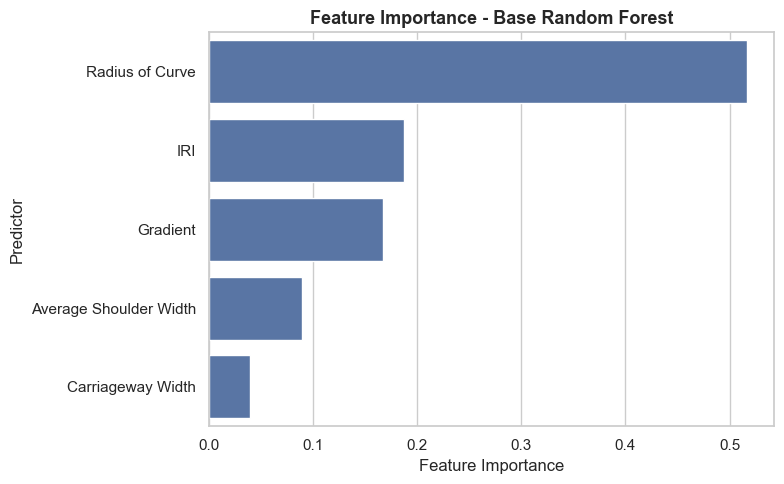

In [72]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance - Base Random Forest",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("Predictor")

plt.tight_layout()
plt.show()

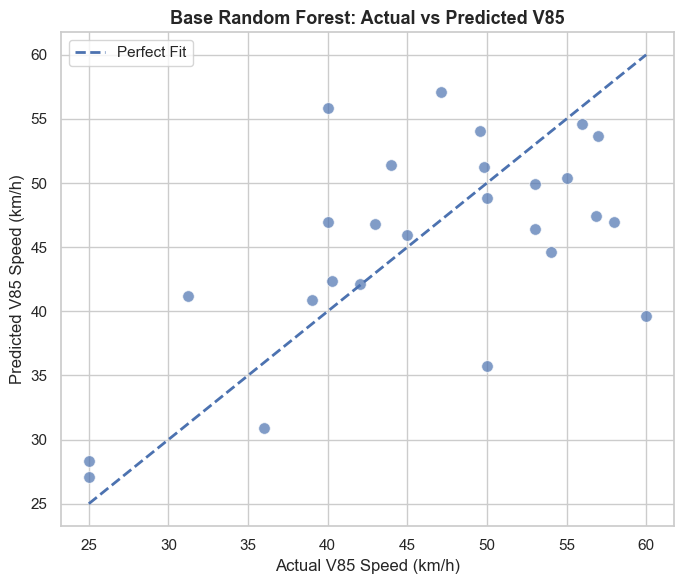

In [73]:
# ============================================================
# RANDOM FOREST: ACTUAL VS PREDICTED
# TEST DATA
# ============================================================

plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_rf,
    s=70,
    alpha=0.7
)

# Perfect prediction line
min_val = min(
    y_test.min(),
    y_test_pred_rf.min()
)

max_val = max(
    y_test.max(),
    y_test_pred_rf.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel(
    "Actual V85 Speed (km/h)"
)

plt.ylabel(
    "Predicted V85 Speed (km/h)"
)

plt.title(
    "Base Random Forest: Actual vs Predicted V85",
    fontsize=13,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()
plt.show()

In [74]:
# ============================================================
# RANDOM FOREST RESIDUALS
# ============================================================

rf_residuals = (
    y_test.values
    - y_test_pred_rf
)

print(
    "Mean Test Residual:",
    round(np.mean(rf_residuals), 3)
)

Mean Test Residual: 0.736


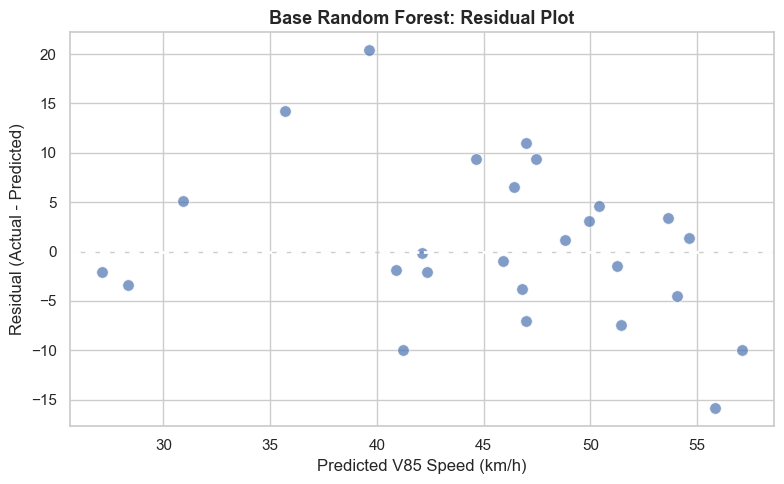

In [75]:
# ============================================================
# RANDOM FOREST: RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test_pred_rf,
    y=rf_residuals,
    s=70,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Predicted V85 Speed (km/h)"
)

plt.ylabel(
    "Residual (Actual - Predicted)"
)

plt.title(
    "Base Random Forest: Residual Plot",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

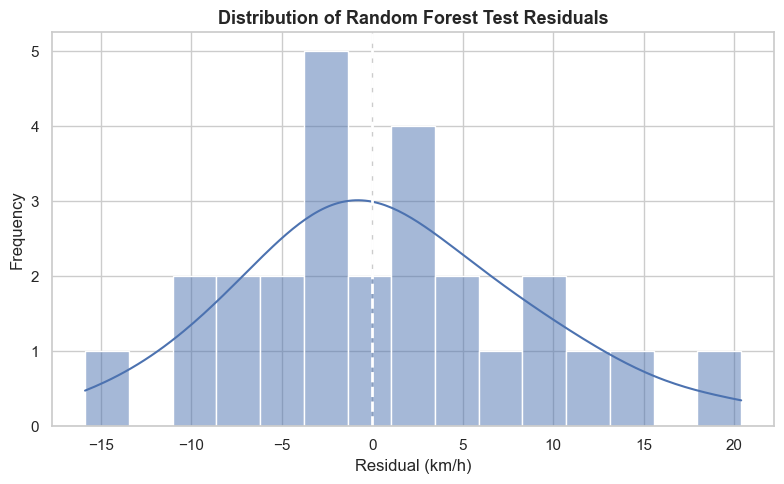

In [76]:
# ============================================================
# RANDOM FOREST RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    rf_residuals,
    bins=15,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual (km/h)")
plt.ylabel("Frequency")

plt.title(
    "Distribution of Random Forest Test Residuals",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [77]:
# ============================================================
# RANDOM FOREST PREDICTION TABLE
# ============================================================

rf_predictions = pd.DataFrame({

    "Actual V85": y_test.values,

    "Predicted V85": y_test_pred_rf,

    "Residual": rf_residuals,

    "Absolute Error": np.abs(
        rf_residuals
    )

})

display(
    rf_predictions.round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
0,58.00,46.97,11.03,11.03
1,56.00,54.64,1.36,1.36
2,40.00,55.86,-15.86,15.86
3,40.25,42.34,-2.09,2.09
4,60.00,39.61,20.39,20.39
5,45.00,45.92,-0.92,0.92
6,56.85,47.47,9.38,9.38
7,44.00,51.44,-7.44,7.44
8,49.80,51.26,-1.46,1.46
9,39.00,40.88,-1.88,1.88


In [78]:
display(
    rf_predictions
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
4,60.00,39.61,20.39,20.39
2,40.00,55.86,-15.86,15.86
10,50.00,35.71,14.29,14.29
0,58.00,46.97,11.03,11.03
11,47.10,57.11,-10.01,10.01
12,31.25,41.21,-9.96,9.96
6,56.85,47.47,9.38,9.38
24,54.00,44.65,9.35,9.35
7,44.00,51.44,-7.44,7.44
23,40.00,47.00,-7.00,7.00


In [79]:
# ============================================================
# FINAL BASE RANDOM FOREST RESULT
# ============================================================

rf_final = pd.DataFrame({

    "Model": [
        "Random Forest"
    ],

    "R²": [
        round(rf_test_r2, 3)
    ],

    "RMSE": [
        round(rf_test_rmse, 3)
    ],

    "MAE": [
        round(rf_test_mae, 3)
    ]

})

display(rf_final)

,Model,R²,RMSE,MAE
0,Random Forest,0.304,7.959,6.157


In [80]:
# ============================================================
# MLR VS BASE RANDOM FOREST
# ============================================================

base_model_comparison = pd.DataFrame({

    "Model": [
        "Multiple Linear Regression",
        "Random Forest"
    ],

    "R²": [
        mlr_test_r2,
        rf_test_r2
    ],

    "RMSE": [
        mlr_test_rmse,
        rf_test_rmse
    ],

    "MAE": [
        mlr_test_mae,
        rf_test_mae
    ]

})

base_model_comparison = (
    base_model_comparison
    .sort_values(
        by="RMSE"
    )
    .reset_index(drop=True)
)

display(
    base_model_comparison.round(3)
)

,Model,R²,RMSE,MAE
0,Random Forest,0.304,7.959,6.157
1,Multiple Linear Regression,0.069,9.204,7.429


In [81]:
# ============================================================
# MODEL 3: HYPERPARAMETER-TUNED RANDOM FOREST
# STEP 1: DEFINE HYPERPARAMETER GRID
# ============================================================

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

print("Random Forest hyperparameter grid created.")

Random Forest hyperparameter grid created.


In [82]:
# ============================================================
# NUMBER OF HYPERPARAMETER COMBINATIONS
# ============================================================

from math import prod

n_combinations = prod(
    len(values)
    for values in param_grid_rf.values()
)

print("Total hyperparameter combinations:", n_combinations)
print("5-fold CV model fits:", n_combinations * 5)

Total hyperparameter combinations: 216
5-fold CV model fits: 1080


In [83]:
# ============================================================
# STEP 3: GRID SEARCH SETUP
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_grid=param_grid_rf,

    cv=5,

    scoring="r2",

    n_jobs=-1,

    verbose=1
)

print("GridSearchCV configured successfully.")

GridSearchCV configured successfully.


In [84]:
# ============================================================
# STEP 4: PERFORM GRID SEARCH
# ============================================================

grid_rf.fit(
    X_train,
    y_train
)

print("\nTuning completed successfully.")

print("\nBest Parameters:")
print(grid_rf.best_params_)

print(
    "\nBest 5-Fold CV R²:",
    round(grid_rf.best_score_, 3)
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Tuning completed successfully.

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best 5-Fold CV R²: 0.28


In [85]:
# ============================================================
# STEP 5: EXTRACT BEST RANDOM FOREST MODEL
# ============================================================

best_rf = grid_rf.best_estimator_

print("Best Tuned Random Forest Model:")
print(best_rf)

Best Tuned Random Forest Model:
RandomForestRegressor(max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, random_state=42)


In [86]:
# ============================================================
# BEST PARAMETERS TABLE
# ============================================================

best_rf_params = pd.DataFrame({
    "Hyperparameter": list(
        grid_rf.best_params_.keys()
    ),

    "Best Value": list(
        grid_rf.best_params_.values()
    )
})

display(best_rf_params)

,Hyperparameter,Best Value
0,max_depth,None
1,max_features,sqrt
2,min_samples_leaf,2
3,min_samples_split,5
4,n_estimators,100


In [87]:
# ============================================================
# STEP 7: TUNED RF PREDICTIONS
# ============================================================

y_train_pred_rf_tuned = best_rf.predict(
    X_train
)

y_test_pred_rf_tuned = best_rf.predict(
    X_test
)

print("Predictions completed.")

Predictions completed.


In [88]:
# ============================================================
# STEP 8: TUNED RANDOM FOREST EVALUATION
# ============================================================

# Training R²
rf_tuned_train_r2 = r2_score(
    y_train,
    y_train_pred_rf_tuned
)

# Testing R²
rf_tuned_test_r2 = r2_score(
    y_test,
    y_test_pred_rf_tuned
)


# Training RMSE
rf_tuned_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_rf_tuned
    )
)

# Testing RMSE
rf_tuned_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_rf_tuned
    )
)


# Training MAE
rf_tuned_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_rf_tuned
)

# Testing MAE
rf_tuned_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_rf_tuned
)

In [89]:
# ============================================================
# TUNED RF PERFORMANCE SUMMARY
# ============================================================

rf_tuned_performance = pd.DataFrame({

    "Dataset": [
        "Training",
        "Testing"
    ],

    "R²": [
        rf_tuned_train_r2,
        rf_tuned_test_r2
    ],

    "RMSE (km/h)": [
        rf_tuned_train_rmse,
        rf_tuned_test_rmse
    ],

    "MAE (km/h)": [
        rf_tuned_train_mae,
        rf_tuned_test_mae
    ]

})

display(
    rf_tuned_performance.round(3)
)

,Dataset,R²,RMSE (km/h),MAE (km/h)
0,Training,0.756,5.207,3.934
1,Testing,0.387,7.467,6.017


In [90]:
print("=" * 60)
print("TUNED RANDOM FOREST PERFORMANCE")
print("=" * 60)

print("\nTRAINING DATA")
print(f"R²   : {rf_tuned_train_r2:.4f}")
print(f"RMSE : {rf_tuned_train_rmse:.4f} km/h")
print(f"MAE  : {rf_tuned_train_mae:.4f} km/h")

print("\nTEST DATA")
print(f"R²   : {rf_tuned_test_r2:.4f}")
print(f"RMSE : {rf_tuned_test_rmse:.4f} km/h")
print(f"MAE  : {rf_tuned_test_mae:.4f} km/h")

print("\nBEST CV R²")
print(f"{grid_rf.best_score_:.4f}")

TUNED RANDOM FOREST PERFORMANCE

TRAINING DATA
R²   : 0.7559
RMSE : 5.2067 km/h
MAE  : 3.9344 km/h

TEST DATA
R²   : 0.3870
RMSE : 7.4674 km/h
MAE  : 6.0171 km/h

BEST CV R²
0.2797


In [91]:
# ============================================================
# TUNED RF TEST RESULT TABLE
# ============================================================

rf_tuned_results = pd.DataFrame({

    "Metric": [
        "R²",
        "RMSE",
        "MAE"
    ],

    "Value": [
        rf_tuned_test_r2,
        rf_tuned_test_rmse,
        rf_tuned_test_mae
    ]

})

display(
    rf_tuned_results.round(3)
)

,Metric,Value
0,R²,0.387
1,RMSE,7.467
2,MAE,6.017


In [92]:
# ============================================================
# BASE RF VS TUNED RF
# ============================================================

rf_comparison = pd.DataFrame({

    "Model": [
        "Base Random Forest",
        "Tuned Random Forest"
    ],

    "Training R²": [
        rf_train_r2,
        rf_tuned_train_r2
    ],

    "Test R²": [
        rf_test_r2,
        rf_tuned_test_r2
    ],

    "Test RMSE": [
        rf_test_rmse,
        rf_tuned_test_rmse
    ],

    "Test MAE": [
        rf_test_mae,
        rf_tuned_test_mae
    ]

})

display(
    rf_comparison.round(3)
)

,Model,Training R²,Test R²,Test RMSE,Test MAE
0,Base Random Forest,0.894,0.304,7.959,6.157
1,Tuned Random Forest,0.756,0.387,7.467,6.017


In [93]:
# ============================================================
# IMPROVEMENT AFTER RF TUNING
# ============================================================

r2_change = (
    rf_tuned_test_r2
    - rf_test_r2
)

rmse_change = (
    rf_test_rmse
    - rf_tuned_test_rmse
)

mae_change = (
    rf_test_mae
    - rf_tuned_test_mae
)

print("Change after tuning")
print("=" * 45)

print(
    f"R² improvement   : {r2_change:+.3f}"
)

print(
    f"RMSE reduction   : {rmse_change:+.3f} km/h"
)

print(
    f"MAE reduction    : {mae_change:+.3f} km/h"
)

Change after tuning
R² improvement   : +0.083
RMSE reduction   : +0.492 km/h
MAE reduction    : +0.140 km/h


In [94]:
# ============================================================
# STEP 13: TUNED RF FEATURE IMPORTANCE
# ============================================================

rf_tuned_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_rf.feature_importances_

})

rf_tuned_importance = (
    rf_tuned_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_tuned_importance.round(4)
)

,Feature,Importance
0,Radius of Curve,0.4694
1,Gradient,0.1959
2,IRI,0.1916
3,Average Shoulder Width,0.0905
4,Carriageway Width,0.0525


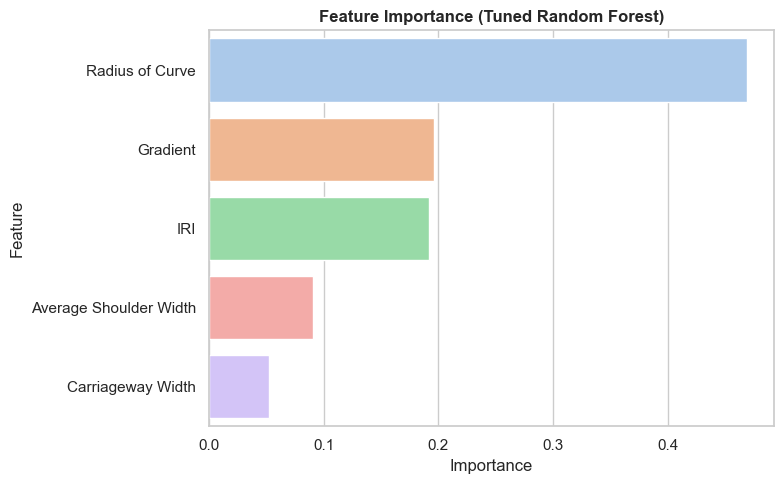

In [95]:
# ============================================================
# TUNED RF FEATURE IMPORTANCE PLOT
# ============================================================

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_tuned_importance,
    palette="pastel"
)

plt.title(
    "Feature Importance (Tuned Random Forest)",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

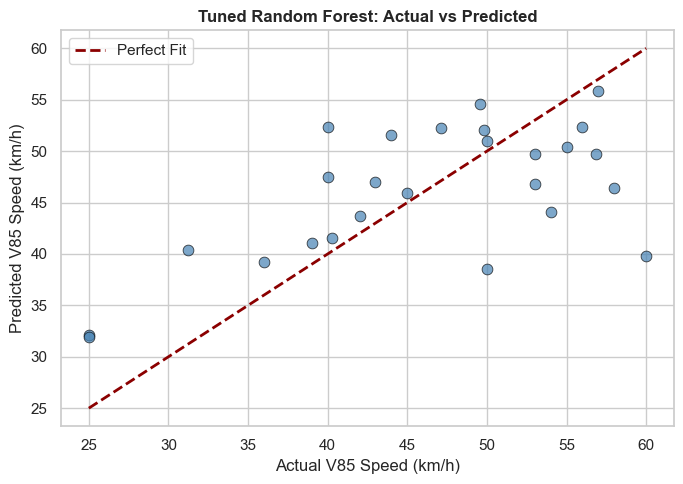

In [96]:
# ============================================================
# TUNED RF: ACTUAL VS PREDICTED
# ============================================================

sns.set_style("whitegrid")

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_rf_tuned,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel(
    "Actual V85 Speed (km/h)"
)

plt.ylabel(
    "Predicted V85 Speed (km/h)"
)

plt.title(
    "Tuned Random Forest: Actual vs Predicted",
    fontsize=12,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()
plt.show()

In [97]:
# ============================================================
# TUNED RF RESIDUALS
# ============================================================

rf_tuned_residuals = (
    y_test.values
    - y_test_pred_rf_tuned
)

print(
    "Mean residual:",
    round(
        rf_tuned_residuals.mean(),
        3
    )
)

Mean residual: 0.08


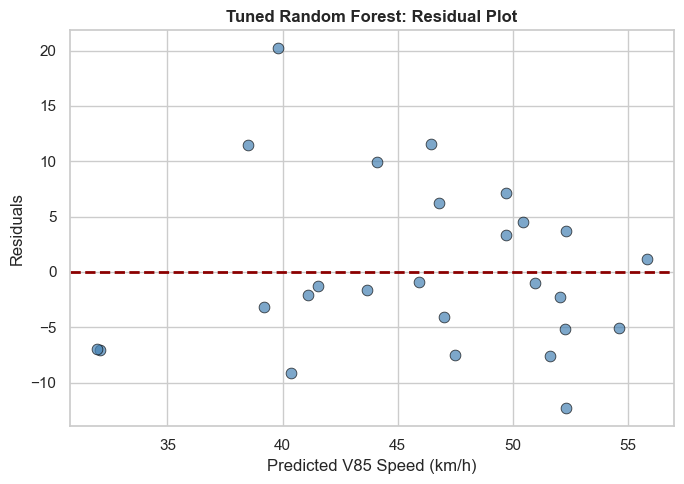

In [98]:
# ============================================================
# TUNED RF RESIDUAL PLOT
# ============================================================

sns.set_style("whitegrid")

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test_pred_rf_tuned,
    y=rf_tuned_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(
    y=0,
    linestyle="--",
    color="darkred",
    linewidth=2
)

plt.xlabel(
    "Predicted V85 Speed (km/h)"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Tuned Random Forest: Residual Plot",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

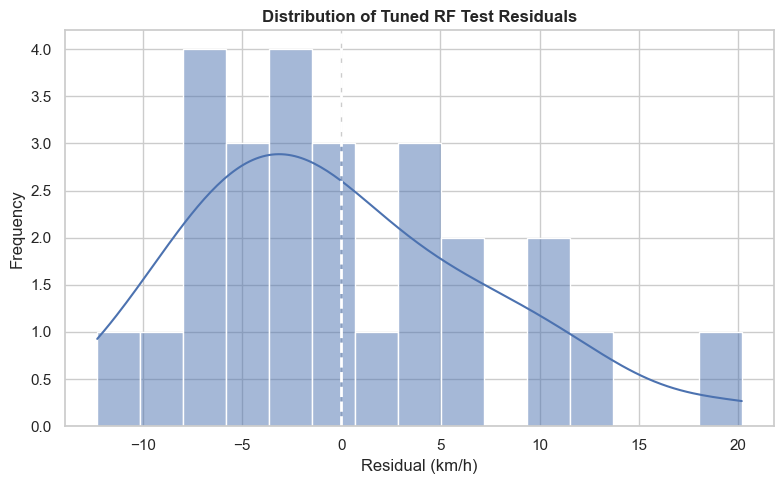

In [99]:
# ============================================================
# TUNED RF RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    rf_tuned_residuals,
    bins=15,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Residual (km/h)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Tuned RF Test Residuals",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [100]:
# ============================================================
# TUNED RF PREDICTION TABLE
# ============================================================

rf_tuned_predictions = pd.DataFrame({

    "Actual V85": y_test.values,

    "Predicted V85":
        y_test_pred_rf_tuned,

    "Residual":
        rf_tuned_residuals,

    "Absolute Error":
        np.abs(rf_tuned_residuals)

})

display(
    rf_tuned_predictions.round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
0,58.00,46.44,11.56,11.56
1,56.00,52.31,3.69,3.69
2,40.00,52.31,-12.31,12.31
3,40.25,41.52,-1.27,1.27
4,60.00,39.80,20.20,20.20
5,45.00,45.93,-0.93,0.93
6,56.85,49.70,7.15,7.15
7,44.00,51.61,-7.61,7.61
8,49.80,52.05,-2.25,2.25
9,39.00,41.10,-2.10,2.10


In [101]:
display(
    rf_tuned_predictions
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
4,60.00,39.80,20.20,20.20
2,40.00,52.31,-12.31,12.31
0,58.00,46.44,11.56,11.56
10,50.00,38.50,11.50,11.50
24,54.00,44.10,9.90,9.90
12,31.25,40.36,-9.11,9.11
7,44.00,51.61,-7.61,7.61
23,40.00,47.49,-7.49,7.49
6,56.85,49.70,7.15,7.15
14,25.00,32.09,-7.09,7.09


In [102]:
# ============================================================
# FINAL TUNED RANDOM FOREST RESULT
# ============================================================

rf_tuned_final = pd.DataFrame({

    "Model": [
        "Tuned Random Forest"
    ],

    "R2": [
        round(
            rf_tuned_test_r2,
            3
        )
    ],

    "RMSE": [
        round(
            rf_tuned_test_rmse,
            3
        )
    ],

    "MAE": [
        round(
            rf_tuned_test_mae,
            3
        )
    ]

})

display(rf_tuned_final)

,Model,R2,RMSE,MAE
0,Tuned Random Forest,0.387,7.467,6.017


In [103]:
# ============================================================
# TOP RANDOM FOREST HYPERPARAMETER COMBINATIONS
# ============================================================

rf_cv_results = pd.DataFrame(
    grid_rf.cv_results_
)

rf_cv_summary = rf_cv_results[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    "rank_test_score"
)

display(
    rf_cv_summary.head(10)
)

,params,mean_test_score,std_test_score,rank_test_score
12,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.279724,0.120596,1
39,"{'max_depth': None, 'max_features': 'log2', 'm...",0.279724,0.120596,1
201,"{'max_depth': 15, 'max_features': 'log2', 'min...",0.279724,0.120596,1
174,"{'max_depth': 15, 'max_features': 'sqrt', 'min...",0.279724,0.120596,1
120,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.279631,0.120437,5
147,"{'max_depth': 10, 'max_features': 'log2', 'min...",0.279631,0.120437,5
138,"{'max_depth': 10, 'max_features': 'log2', 'min...",0.267031,0.162351,7
111,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.267031,0.162351,7
30,"{'max_depth': None, 'max_features': 'log2', 'm...",0.266817,0.158783,9
3,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.266817,0.158783,9


In [104]:
# ============================================================
# MODEL 4: BASE XGBOOST REGRESSION
# ============================================================

from xgboost import XGBRegressor

In [109]:
# ============================================================
# BASE XGBOOST MODEL
# ============================================================

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print(xgb)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=-1, num_parallel_tree=None, ...)


In [110]:
# ============================================================
# TRAIN BASE XGBOOST
# ============================================================

xgb.fit(
    X_train,
    y_train
)

print("Base XGBoost model trained successfully.")

Base XGBoost model trained successfully.


In [111]:
# ============================================================
# BASE XGBOOST PREDICTIONS
# ============================================================

y_train_pred_xgb = xgb.predict(
    X_train
)

y_test_pred_xgb = xgb.predict(
    X_test
)

print("Predictions completed.")

Predictions completed.


In [112]:
# ============================================================
# XGBOOST TRAINING PERFORMANCE
# ============================================================

xgb_train_r2 = r2_score(
    y_train,
    y_train_pred_xgb
)

xgb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_xgb
    )
)

xgb_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_xgb
)

In [113]:
# ============================================================
# XGBOOST TEST PERFORMANCE
# ============================================================

xgb_test_r2 = r2_score(
    y_test,
    y_test_pred_xgb
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_xgb
    )
)

xgb_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_xgb
)

In [114]:
# ============================================================
# BASE XGBOOST PERFORMANCE SUMMARY
# ============================================================

print("=" * 55)
print("BASE XGBOOST PERFORMANCE")
print("=" * 55)

print("\nTRAINING DATA")
print(f"R²   : {xgb_train_r2:.4f}")
print(f"RMSE : {xgb_train_rmse:.4f} km/h")
print(f"MAE  : {xgb_train_mae:.4f} km/h")

print("\nTEST DATA")
print(f"R²   : {xgb_test_r2:.4f}")
print(f"RMSE : {xgb_test_rmse:.4f} km/h")
print(f"MAE  : {xgb_test_mae:.4f} km/h")

BASE XGBOOST PERFORMANCE

TRAINING DATA
R²   : 1.0000
RMSE : 0.0016 km/h
MAE  : 0.0011 km/h

TEST DATA
R²   : 0.1175
RMSE : 8.9594 km/h
MAE  : 6.3742 km/h


In [115]:
xgb_performance = pd.DataFrame({

    "Dataset": [
        "Training",
        "Testing"
    ],

    "R²": [
        xgb_train_r2,
        xgb_test_r2
    ],

    "RMSE (km/h)": [
        xgb_train_rmse,
        xgb_test_rmse
    ],

    "MAE (km/h)": [
        xgb_train_mae,
        xgb_test_mae
    ]
})

display(
    xgb_performance.round(3)
)

,Dataset,R²,RMSE (km/h),MAE (km/h)
0,Training,1.000,0.002,0.001
1,Testing,0.118,8.959,6.374


In [116]:
# ============================================================
# BASE XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb.feature_importances_

})

xgb_importance = (
    xgb_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    xgb_importance.round(4)
)

,Feature,Importance
0,Radius of Curve,0.5275
1,Average Shoulder Width,0.2459
2,IRI,0.0985
3,Gradient,0.0658
4,Carriageway Width,0.0624


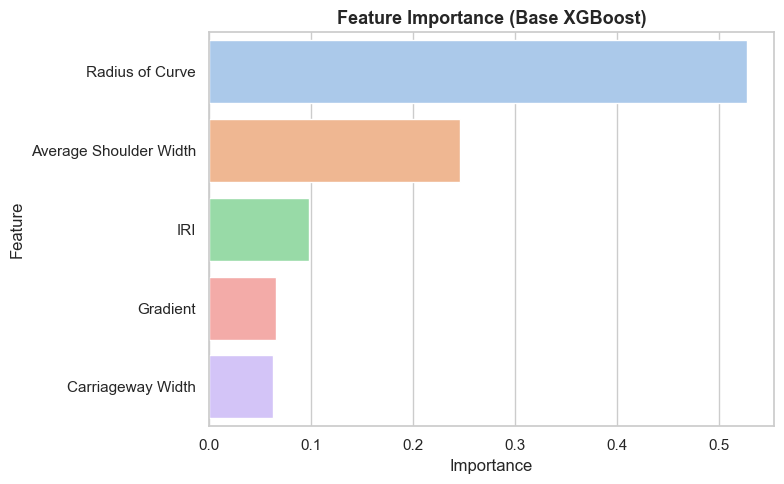

In [117]:
# ============================================================
# BASE XGBOOST FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature",
    palette="pastel"
)

plt.title(
    "Feature Importance (Base XGBoost)",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

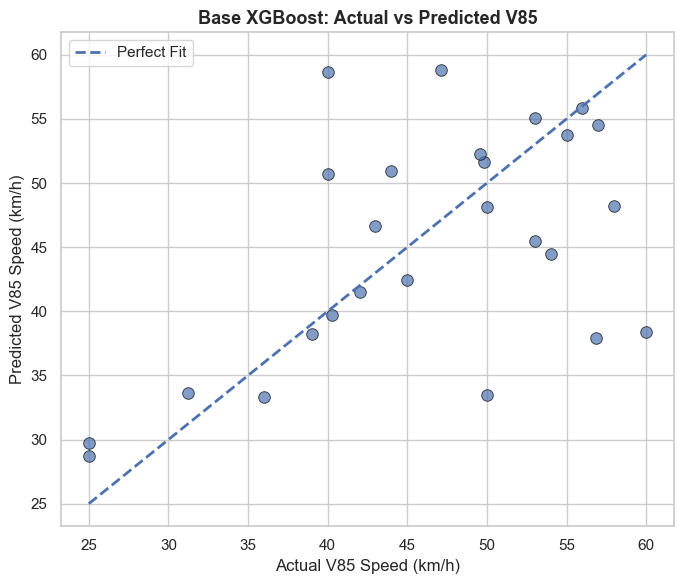

In [118]:
# ============================================================
# BASE XGBOOST: ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_xgb,
    s=70,
    alpha=0.7,
    edgecolor="black"
)

min_val = min(
    y_test.min(),
    y_test_pred_xgb.min()
)

max_val = max(
    y_test.max(),
    y_test_pred_xgb.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel(
    "Actual V85 Speed (km/h)"
)

plt.ylabel(
    "Predicted V85 Speed (km/h)"
)

plt.title(
    "Base XGBoost: Actual vs Predicted V85",
    fontsize=13,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()
plt.show()

In [119]:
# ============================================================
# BASE XGBOOST RESIDUALS
# ============================================================

xgb_residuals = (
    y_test.values
    - y_test_pred_xgb
)

print(
    "Mean Test Residual:",
    round(
        np.mean(xgb_residuals),
        3
    )
)

Mean Test Residual: 1.061


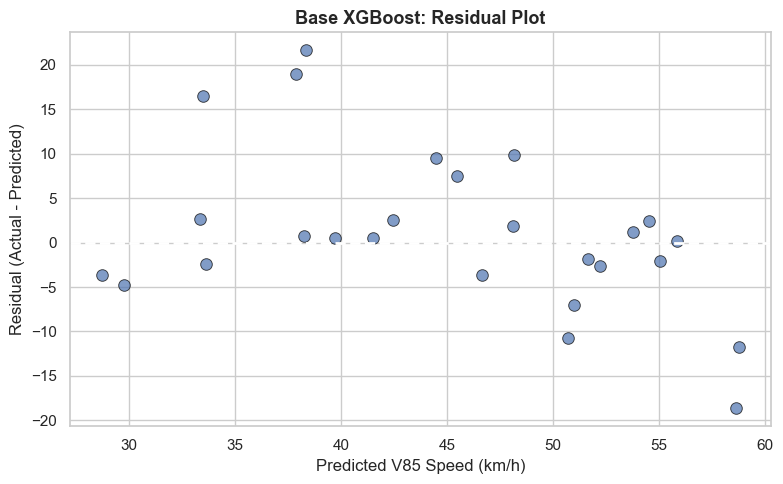

In [120]:
# ============================================================
# BASE XGBOOST RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test_pred_xgb,
    y=xgb_residuals,
    s=70,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Predicted V85 Speed (km/h)"
)

plt.ylabel(
    "Residual (Actual - Predicted)"
)

plt.title(
    "Base XGBoost: Residual Plot",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

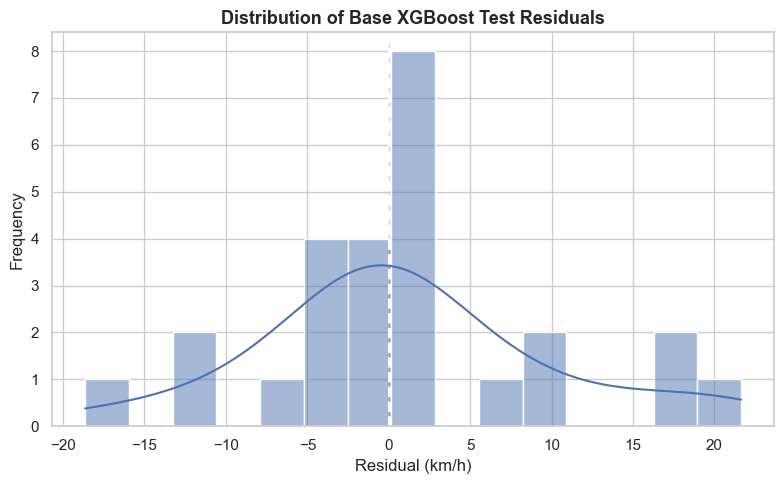

In [121]:
# ============================================================
# BASE XGBOOST RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    xgb_residuals,
    bins=15,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Residual (km/h)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Base XGBoost Test Residuals",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [122]:
# ============================================================
# BASE XGBOOST PREDICTION TABLE
# ============================================================

xgb_predictions = pd.DataFrame({

    "Actual V85":
        y_test.values,

    "Predicted V85":
        y_test_pred_xgb,

    "Residual":
        xgb_residuals,

    "Absolute Error":
        np.abs(xgb_residuals)

})

display(
    xgb_predictions.round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
0,58.00,48.180000,9.82,9.82
1,56.00,55.849998,0.15,0.15
2,40.00,58.639999,-18.64,18.64
3,40.25,39.720001,0.53,0.53
4,60.00,38.360001,21.64,21.64
5,45.00,42.430000,2.57,2.57
6,56.85,37.900002,18.95,18.95
7,44.00,50.980000,-6.98,6.98
8,49.80,51.660000,-1.86,1.86
9,39.00,38.259998,0.74,0.74


In [123]:
display(
    xgb_predictions
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
4,60.00,38.360001,21.64,21.64
6,56.85,37.900002,18.95,18.95
2,40.00,58.639999,-18.64,18.64
10,50.00,33.490002,16.51,16.51
11,47.10,58.799999,-11.70,11.70
23,40.00,50.720001,-10.72,10.72
0,58.00,48.180000,9.82,9.82
24,54.00,44.490002,9.51,9.51
19,53.00,45.500000,7.50,7.50
7,44.00,50.980000,-6.98,6.98


In [124]:
# ============================================================
# FINAL BASE XGBOOST RESULT
# ============================================================

xgb_final = pd.DataFrame({

    "Model": [
        "Base XGBoost"
    ],

    "R2": [
        round(
            xgb_test_r2,
            3
        )
    ],

    "RMSE": [
        round(
            xgb_test_rmse,
            3
        )
    ],

    "MAE": [
        round(
            xgb_test_mae,
            3
        )
    ]
})

display(xgb_final)

,Model,R2,RMSE,MAE
0,Base XGBoost,0.118,8.959,6.374


In [125]:
# ============================================================
# MODEL COMPARISON SO FAR
# ============================================================

model_comparison_so_far = pd.DataFrame({

    "Model": [
        "Multiple Linear Regression",
        "Base Random Forest",
        "Tuned Random Forest",
        "Base XGBoost"
    ],

    "Test R²": [
        mlr_test_r2,
        rf_test_r2,
        rf_tuned_test_r2,
        xgb_test_r2
    ],

    "Test RMSE": [
        mlr_test_rmse,
        rf_test_rmse,
        rf_tuned_test_rmse,
        xgb_test_rmse
    ],

    "Test MAE": [
        mlr_test_mae,
        rf_test_mae,
        rf_tuned_test_mae,
        xgb_test_mae
    ]
})

model_comparison_so_far = (
    model_comparison_so_far
    .sort_values(
        by="Test RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    model_comparison_so_far.round(3)
)

,Model,Test R²,Test RMSE,Test MAE
0,Tuned Random Forest,0.387,7.467,6.017
1,Base Random Forest,0.304,7.959,6.157
2,Base XGBoost,0.118,8.959,6.374
3,Multiple Linear Regression,0.069,9.204,7.429


In [126]:
# ============================================================
# MODEL 5: TUNED XGBOOST
# ============================================================

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

In [127]:
# ============================================================
# STEP 1: DEFINE XGBOOST HYPERPARAMETER GRID
# ============================================================

param_grid_xgb = {

    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        3,
        5,
        7
    ],

    "learning_rate": [
        0.01,
        0.05,
        0.10
    ],

    "subsample": [
        0.8,
        1.0
    ],

    "colsample_bytree": [
        0.8,
        1.0
    ]
}

print("XGBoost parameter grid created successfully.")

XGBoost parameter grid created successfully.


In [128]:
# ============================================================
# NUMBER OF PARAMETER COMBINATIONS
# ============================================================

from math import prod

n_combinations_xgb = prod(
    len(values)
    for values in param_grid_xgb.values()
)

print(
    "Total hyperparameter combinations:",
    n_combinations_xgb
)

print(
    "Total model fits using 5-fold CV:",
    n_combinations_xgb * 5
)

Total hyperparameter combinations: 108
Total model fits using 5-fold CV: 540


In [129]:
# ============================================================
# STEP 2: CONFIGURE GRIDSEARCHCV
# ============================================================

grid_xgb = GridSearchCV(

    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1
    ),

    param_grid=param_grid_xgb,

    cv=5,

    scoring="r2",

    n_jobs=-1,

    verbose=1,

    return_train_score=True
)

print("XGBoost GridSearchCV configured successfully.")

XGBoost GridSearchCV configured successfully.


In [130]:
# ============================================================
# STEP 3: TUNE XGBOOST USING TRAINING DATA ONLY
# ============================================================

grid_xgb.fit(
    X_train,
    y_train
)

print("\nXGBoost tuning completed.")

print("\nBest Parameters:")
print(grid_xgb.best_params_)

print(
    "\nBest Mean 5-Fold CV R²:",
    round(
        grid_xgb.best_score_,
        4
    )
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits

XGBoost tuning completed.

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}

Best Mean 5-Fold CV R²: 0.2187


In [131]:
# ============================================================
# STEP 4: EXTRACT BEST XGBOOST MODEL
# ============================================================

best_xgb = grid_xgb.best_estimator_

print("Best XGBoost Model:")
print(best_xgb)

Best XGBoost Model:
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=1, num_parallel_tree=None, ...)


In [132]:
# ============================================================
# BEST XGBOOST PARAMETERS
# ============================================================

best_xgb_params = pd.DataFrame({

    "Hyperparameter":
        list(grid_xgb.best_params_.keys()),

    "Best Value":
        list(grid_xgb.best_params_.values())

})

display(best_xgb_params)

,Hyperparameter,Best Value
0,colsample_bytree,0.80
1,learning_rate,0.01
2,max_depth,3.00
3,n_estimators,300.00
4,subsample,1.00


In [133]:
# ============================================================
# STEP 5: TUNED XGBOOST PREDICTIONS
# ============================================================

y_train_pred_xgb_tuned = best_xgb.predict(
    X_train
)

y_test_pred_xgb_tuned = best_xgb.predict(
    X_test
)

print("Predictions completed.")

Predictions completed.


In [134]:
# ============================================================
# TUNED XGBOOST TRAINING METRICS
# ============================================================

xgb_tuned_train_r2 = r2_score(
    y_train,
    y_train_pred_xgb_tuned
)

xgb_tuned_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_xgb_tuned
    )
)

xgb_tuned_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_xgb_tuned
)

In [135]:
# ============================================================
# TUNED XGBOOST TEST METRICS
# ============================================================

xgb_tuned_test_r2 = r2_score(
    y_test,
    y_test_pred_xgb_tuned
)

xgb_tuned_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_xgb_tuned
    )
)

xgb_tuned_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_xgb_tuned
)

In [136]:
# ============================================================
# TUNED XGBOOST PERFORMANCE
# ============================================================

xgb_tuned_performance = pd.DataFrame({

    "Dataset": [
        "Training",
        "Testing"
    ],

    "R²": [
        xgb_tuned_train_r2,
        xgb_tuned_test_r2
    ],

    "RMSE (km/h)": [
        xgb_tuned_train_rmse,
        xgb_tuned_test_rmse
    ],

    "MAE (km/h)": [
        xgb_tuned_train_mae,
        xgb_tuned_test_mae
    ]
})

display(
    xgb_tuned_performance.round(3)
)

,Dataset,R²,RMSE (km/h),MAE (km/h)
0,Training,0.708,5.690,4.241
1,Testing,0.429,7.209,5.506


In [137]:
print("=" * 60)
print("TUNED XGBOOST PERFORMANCE")
print("=" * 60)

print("\nTRAINING")
print(f"R²   : {xgb_tuned_train_r2:.4f}")
print(f"RMSE : {xgb_tuned_train_rmse:.4f} km/h")
print(f"MAE  : {xgb_tuned_train_mae:.4f} km/h")

print("\nTESTING")
print(f"R²   : {xgb_tuned_test_r2:.4f}")
print(f"RMSE : {xgb_tuned_test_rmse:.4f} km/h")
print(f"MAE  : {xgb_tuned_test_mae:.4f} km/h")

print("\nBEST 5-FOLD CV R²")
print(f"{grid_xgb.best_score_:.4f}")

TUNED XGBOOST PERFORMANCE

TRAINING
R²   : 0.7085
RMSE : 5.6902 km/h
MAE  : 4.2409 km/h

TESTING
R²   : 0.4287
RMSE : 7.2087 km/h
MAE  : 5.5064 km/h

BEST 5-FOLD CV R²
0.2187


In [138]:
# ============================================================
# BASE XGBOOST VS TUNED XGBOOST
# ============================================================

xgb_comparison = pd.DataFrame({

    "Model": [
        "Base XGBoost",
        "Tuned XGBoost"
    ],

    "Training R²": [
        xgb_train_r2,
        xgb_tuned_train_r2
    ],

    "Test R²": [
        xgb_test_r2,
        xgb_tuned_test_r2
    ],

    "Test RMSE": [
        xgb_test_rmse,
        xgb_tuned_test_rmse
    ],

    "Test MAE": [
        xgb_test_mae,
        xgb_tuned_test_mae
    ]
})

display(
    xgb_comparison.round(3)
)

,Model,Training R²,Test R²,Test RMSE,Test MAE
0,Base XGBoost,1.000,0.118,8.959,6.374
1,Tuned XGBoost,0.708,0.429,7.209,5.506


In [139]:
# ============================================================
# EFFECT OF XGBOOST TUNING
# ============================================================

xgb_r2_improvement = (
    xgb_tuned_test_r2
    - xgb_test_r2
)

xgb_rmse_reduction = (
    xgb_test_rmse
    - xgb_tuned_test_rmse
)

xgb_mae_reduction = (
    xgb_test_mae
    - xgb_tuned_test_mae
)

print("=" * 50)
print("IMPROVEMENT AFTER XGBOOST TUNING")
print("=" * 50)

print(
    f"R² improvement : "
    f"{xgb_r2_improvement:+.3f}"
)

print(
    f"RMSE reduction : "
    f"{xgb_rmse_reduction:+.3f} km/h"
)

print(
    f"MAE reduction  : "
    f"{xgb_mae_reduction:+.3f} km/h"
)

IMPROVEMENT AFTER XGBOOST TUNING
R² improvement : +0.311
RMSE reduction : +1.751 km/h
MAE reduction  : +0.868 km/h


In [140]:
# ============================================================
# TUNED XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_tuned_importance = pd.DataFrame({

    "Feature":
        X.columns,

    "Importance":
        best_xgb.feature_importances_

})

xgb_tuned_importance = (
    xgb_tuned_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    xgb_tuned_importance.round(4)
)

,Feature,Importance
0,Radius of Curve,0.5114
1,IRI,0.1641
2,Gradient,0.1256
3,Average Shoulder Width,0.1150
4,Carriageway Width,0.0839


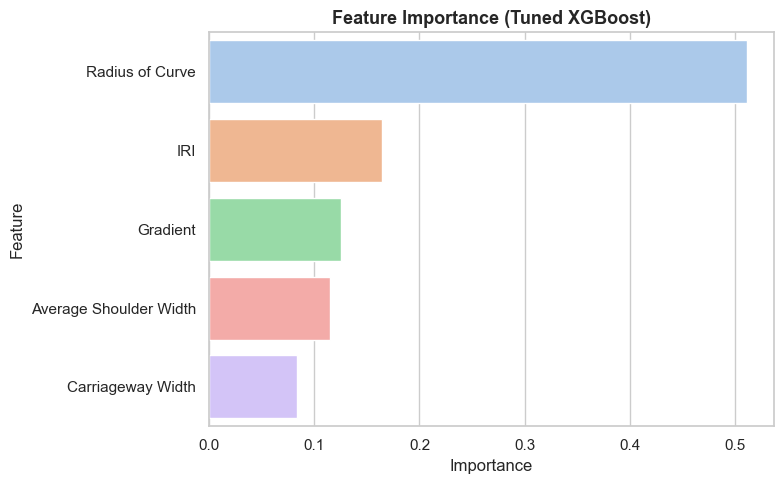

In [141]:
# ============================================================
# TUNED XGBOOST FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=xgb_tuned_importance,
    x="Importance",
    y="Feature",
    palette="pastel"
)

plt.title(
    "Feature Importance (Tuned XGBoost)",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

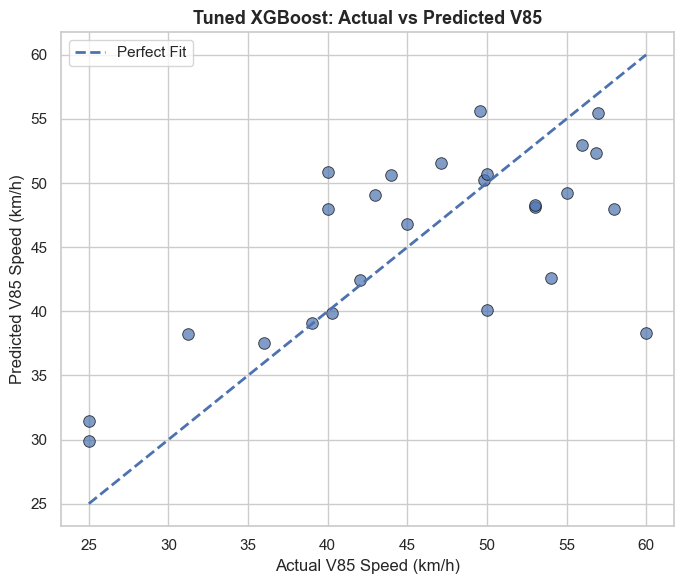

In [142]:
# ============================================================
# TUNED XGBOOST: ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_xgb_tuned,
    s=70,
    alpha=0.7,
    edgecolor="black"
)

min_val = min(
    y_test.min(),
    y_test_pred_xgb_tuned.min()
)

max_val = max(
    y_test.max(),
    y_test_pred_xgb_tuned.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel(
    "Actual V85 Speed (km/h)"
)

plt.ylabel(
    "Predicted V85 Speed (km/h)"
)

plt.title(
    "Tuned XGBoost: Actual vs Predicted V85",
    fontsize=13,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()
plt.show()

In [143]:
# ============================================================
# TUNED XGBOOST RESIDUALS
# ============================================================

xgb_tuned_residuals = (
    y_test.values
    - y_test_pred_xgb_tuned
)

print(
    "Mean Test Residual:",
    round(
        np.mean(xgb_tuned_residuals),
        3
    )
)

Mean Test Residual: 0.474


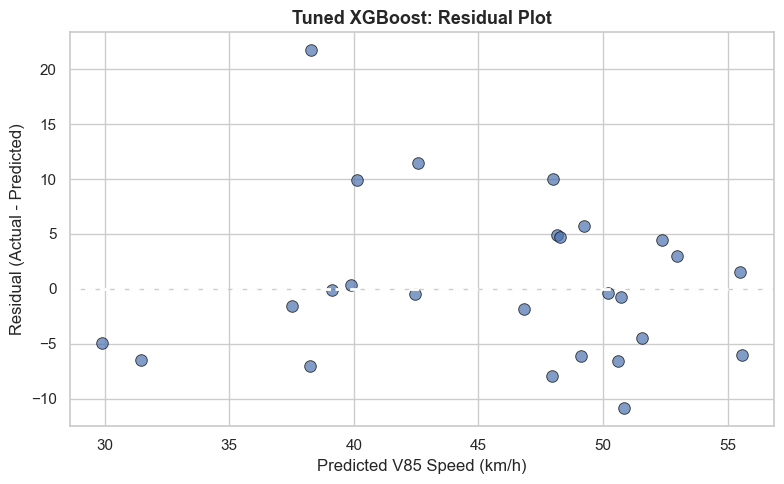

In [144]:
# ============================================================
# TUNED XGBOOST RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test_pred_xgb_tuned,
    y=xgb_tuned_residuals,
    s=70,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Predicted V85 Speed (km/h)"
)

plt.ylabel(
    "Residual (Actual - Predicted)"
)

plt.title(
    "Tuned XGBoost: Residual Plot",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

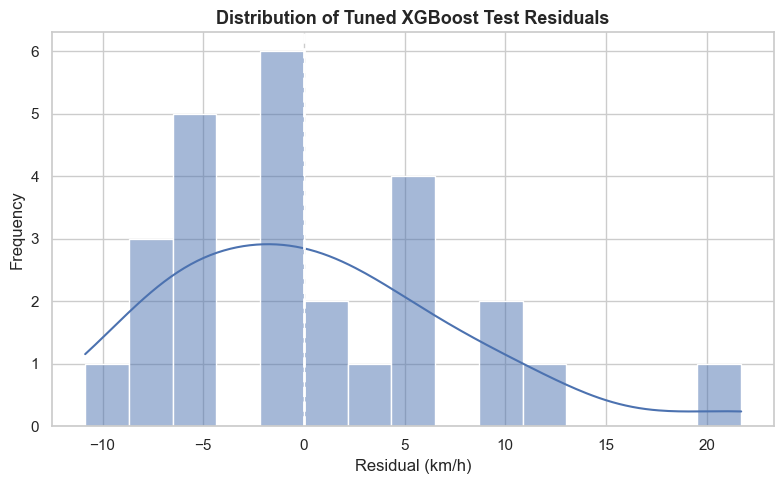

In [145]:
# ============================================================
# TUNED XGBOOST RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    xgb_tuned_residuals,
    bins=15,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Residual (km/h)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Tuned XGBoost Test Residuals",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [146]:
# ============================================================
# TUNED XGBOOST PREDICTION TABLE
# ============================================================

xgb_tuned_predictions = pd.DataFrame({

    "Actual V85":
        y_test.values,

    "Predicted V85":
        y_test_pred_xgb_tuned,

    "Residual":
        xgb_tuned_residuals,

    "Absolute Error":
        np.abs(
            xgb_tuned_residuals
        )
})

display(
    xgb_tuned_predictions.round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
0,58.00,47.990002,10.01,10.01
1,56.00,52.990002,3.01,3.01
2,40.00,50.860001,-10.86,10.86
3,40.25,39.900002,0.35,0.35
4,60.00,38.279999,21.72,21.72
5,45.00,46.810001,-1.81,1.81
6,56.85,52.360001,4.49,4.49
7,44.00,50.610001,-6.61,6.61
8,49.80,50.209999,-0.41,0.41
9,39.00,39.130001,-0.13,0.13


In [147]:
display(
    xgb_tuned_predictions
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
4,60.00,38.279999,21.72,21.72
24,54.00,42.560001,11.44,11.44
2,40.00,50.860001,-10.86,10.86
0,58.00,47.990002,10.01,10.01
10,50.00,40.119999,9.88,9.88
23,40.00,47.959999,-7.96,7.96
12,31.25,38.259998,-7.01,7.01
7,44.00,50.610001,-6.61,6.61
14,25.00,31.459999,-6.46,6.46
20,43.00,49.099998,-6.10,6.10


In [148]:
# ============================================================
# TOP XGBOOST HYPERPARAMETER COMBINATIONS
# ============================================================

xgb_cv_results = pd.DataFrame(
    grid_xgb.cv_results_
)

xgb_cv_summary = xgb_cv_results[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    by="rank_test_score"
)

display(
    xgb_cv_summary.head(10)
)

,params,mean_test_score,std_test_score,rank_test_score
5,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.218693,0.134445,1
4,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.213901,0.159612,2
3,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.209448,0.133005,3
56,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.207601,0.182950,4
2,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.206053,0.165759,5
18,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.204694,0.152624,6
58,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.202636,0.175824,7
72,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.189186,0.199139,8
9,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.188073,0.164376,9
8,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.187116,0.170342,10


In [149]:
# ============================================================
# FINAL TUNED XGBOOST RESULT
# ============================================================

xgb_tuned_final = pd.DataFrame({

    "Model": [
        "Tuned XGBoost"
    ],

    "R2": [
        round(
            xgb_tuned_test_r2,
            3
        )
    ],

    "RMSE": [
        round(
            xgb_tuned_test_rmse,
            3
        )
    ],

    "MAE": [
        round(
            xgb_tuned_test_mae,
            3
        )
    ]
})

display(xgb_tuned_final)

,Model,R2,RMSE,MAE
0,Tuned XGBoost,0.429,7.209,5.506


In [150]:
# ============================================================
# RANDOM FOREST VS XGBOOST
# ============================================================

tree_model_comparison = pd.DataFrame({

    "Model": [
        "Base Random Forest",
        "Tuned Random Forest",
        "Base XGBoost",
        "Tuned XGBoost"
    ],

    "Test R²": [
        rf_test_r2,
        rf_tuned_test_r2,
        xgb_test_r2,
        xgb_tuned_test_r2
    ],

    "Test RMSE": [
        rf_test_rmse,
        rf_tuned_test_rmse,
        xgb_test_rmse,
        xgb_tuned_test_rmse
    ],

    "Test MAE": [
        rf_test_mae,
        rf_tuned_test_mae,
        xgb_test_mae,
        xgb_tuned_test_mae
    ]
})

tree_model_comparison = (
    tree_model_comparison
    .sort_values(
        by="Test RMSE"
    )
    .reset_index(drop=True)
)

display(
    tree_model_comparison.round(3)
)

,Model,Test R²,Test RMSE,Test MAE
0,Tuned XGBoost,0.429,7.209,5.506
1,Tuned Random Forest,0.387,7.467,6.017
2,Base Random Forest,0.304,7.959,6.157
3,Base XGBoost,0.118,8.959,6.374


In [151]:
# ============================================================
# MODEL 6: BASE SUPPORT VECTOR REGRESSION
# ============================================================

from sklearn.svm import SVR

In [152]:
# ============================================================
# BASE SVR MODEL
# ============================================================

svr = SVR()

print(svr)

SVR()


In [153]:
# ============================================================
# TRAIN BASE SVR
# ============================================================

svr.fit(
    X_train_scaled,
    y_train
)

print("Base SVR model trained successfully.")

Base SVR model trained successfully.


In [154]:
# ============================================================
# BASE SVR PREDICTIONS
# ============================================================

y_train_pred_svr = svr.predict(
    X_train_scaled
)

y_test_pred_svr = svr.predict(
    X_test_scaled
)

print("SVR predictions completed.")

SVR predictions completed.


In [155]:
# ============================================================
# BASE SVR TRAINING PERFORMANCE
# ============================================================

svr_train_r2 = r2_score(
    y_train,
    y_train_pred_svr
)

svr_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_svr
    )
)

svr_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_svr
)

In [156]:
# ============================================================
# BASE SVR TEST PERFORMANCE
# ============================================================

svr_test_r2 = r2_score(
    y_test,
    y_test_pred_svr
)

svr_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_svr
    )
)

svr_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_svr
)

In [157]:
# ============================================================
# BASE SVR PERFORMANCE SUMMARY
# ============================================================

print("=" * 55)
print("BASE SVR PERFORMANCE")
print("=" * 55)

print("\nTRAINING DATA")
print(f"R²   : {svr_train_r2:.4f}")
print(f"RMSE : {svr_train_rmse:.4f} km/h")
print(f"MAE  : {svr_train_mae:.4f} km/h")

print("\nTEST DATA")
print(f"R²   : {svr_test_r2:.4f}")
print(f"RMSE : {svr_test_rmse:.4f} km/h")
print(f"MAE  : {svr_test_mae:.4f} km/h")

BASE SVR PERFORMANCE

TRAINING DATA
R²   : 0.2304
RMSE : 9.2455 km/h
MAE  : 7.0700 km/h

TEST DATA
R²   : 0.1119
RMSE : 8.9882 km/h
MAE  : 7.3068 km/h


In [158]:
svr_performance = pd.DataFrame({

    "Dataset": [
        "Training",
        "Testing"
    ],

    "R²": [
        svr_train_r2,
        svr_test_r2
    ],

    "RMSE (km/h)": [
        svr_train_rmse,
        svr_test_rmse
    ],

    "MAE (km/h)": [
        svr_train_mae,
        svr_test_mae
    ]
})

display(
    svr_performance.round(3)
)

,Dataset,R²,RMSE (km/h),MAE (km/h)
0,Training,0.230,9.246,7.070
1,Testing,0.112,8.988,7.307


In [159]:
# ============================================================
# NUMBER OF SUPPORT VECTORS
# ============================================================

print(
    "Number of Support Vectors:",
    len(svr.support_)
)

print(
    "Percentage of training observations used as support vectors:",
    round(
        len(svr.support_) / len(X_train_scaled) * 100,
        2
    ),
    "%"
)

Number of Support Vectors: 104
Percentage of training observations used as support vectors: 100.0 %


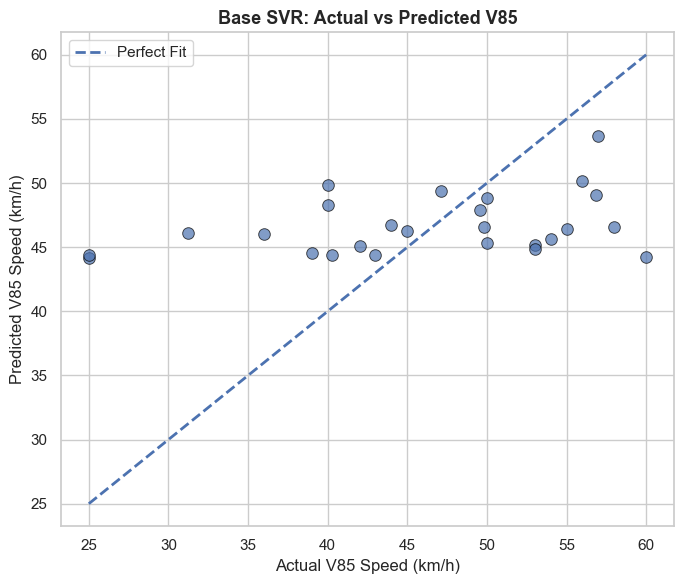

In [160]:
# ============================================================
# BASE SVR: ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_svr,
    s=70,
    alpha=0.7,
    edgecolor="black"
)

min_val = min(
    y_test.min(),
    y_test_pred_svr.min()
)

max_val = max(
    y_test.max(),
    y_test_pred_svr.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel(
    "Actual V85 Speed (km/h)"
)

plt.ylabel(
    "Predicted V85 Speed (km/h)"
)

plt.title(
    "Base SVR: Actual vs Predicted V85",
    fontsize=13,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()
plt.show()

In [161]:
# ============================================================
# BASE SVR RESIDUALS
# ============================================================

svr_residuals = (
    y_test.values
    - y_test_pred_svr
)

print(
    "Mean Test Residual:",
    round(
        np.mean(svr_residuals),
        3
    )
)

Mean Test Residual: -0.55


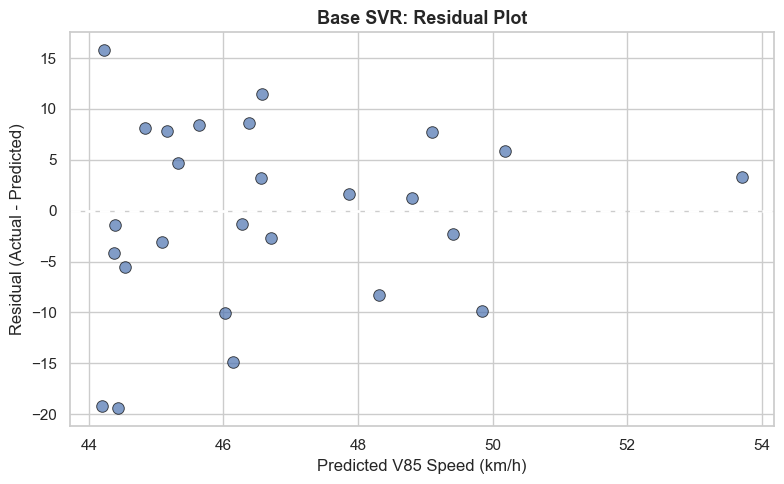

In [162]:
# ============================================================
# BASE SVR RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test_pred_svr,
    y=svr_residuals,
    s=70,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Predicted V85 Speed (km/h)"
)

plt.ylabel(
    "Residual (Actual - Predicted)"
)

plt.title(
    "Base SVR: Residual Plot",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

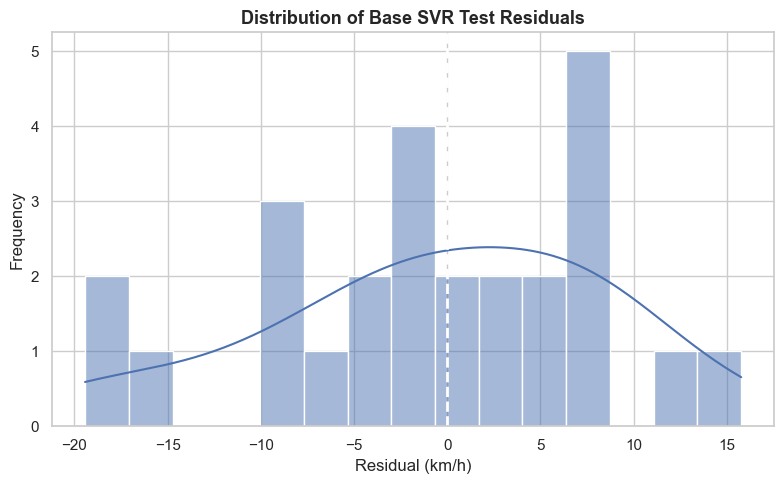

In [163]:
# ============================================================
# BASE SVR RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    svr_residuals,
    bins=15,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Residual (km/h)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Base SVR Test Residuals",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [164]:
# ============================================================
# BASE SVR PREDICTION TABLE
# ============================================================

svr_predictions = pd.DataFrame({

    "Actual V85":
        y_test.values,

    "Predicted V85":
        y_test_pred_svr,

    "Residual":
        svr_residuals,

    "Absolute Error":
        np.abs(svr_residuals)
})

display(
    svr_predictions.round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
0,58.00,46.57,11.43,11.43
1,56.00,50.18,5.82,5.82
2,40.00,49.84,-9.84,9.84
3,40.25,44.38,-4.13,4.13
4,60.00,44.23,15.77,15.77
5,45.00,46.28,-1.28,1.28
6,56.85,49.10,7.75,7.75
7,44.00,46.71,-2.71,2.71
8,49.80,46.55,3.25,3.25
9,39.00,44.54,-5.54,5.54


In [165]:
display(
    svr_predictions
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
17,25.00,44.43,-19.43,19.43
14,25.00,44.19,-19.19,19.19
4,60.00,44.23,15.77,15.77
12,31.25,46.14,-14.89,14.89
0,58.00,46.57,11.43,11.43
13,36.00,46.02,-10.02,10.02
2,40.00,49.84,-9.84,9.84
22,55.00,46.38,8.62,8.62
24,54.00,45.63,8.37,8.37
23,40.00,48.32,-8.32,8.32


In [166]:
# ============================================================
# FINAL BASE SVR RESULT
# ============================================================

svr_final = pd.DataFrame({

    "Model": [
        "Base SVR"
    ],

    "R2": [
        round(
            svr_test_r2,
            3
        )
    ],

    "RMSE": [
        round(
            svr_test_rmse,
            3
        )
    ],

    "MAE": [
        round(
            svr_test_mae,
            3
        )
    ]
})

display(svr_final)

,Model,R2,RMSE,MAE
0,Base SVR,0.112,8.988,7.307


In [167]:
# ============================================================
# MODEL COMPARISON SO FAR
# ============================================================

model_comparison_so_far = pd.DataFrame({

    "Model": [
        "Multiple Linear Regression",
        "Base Random Forest",
        "Tuned Random Forest",
        "Base XGBoost",
        "Tuned XGBoost",
        "Base SVR"
    ],

    "Test R²": [
        mlr_test_r2,
        rf_test_r2,
        rf_tuned_test_r2,
        xgb_test_r2,
        xgb_tuned_test_r2,
        svr_test_r2
    ],

    "Test RMSE": [
        mlr_test_rmse,
        rf_test_rmse,
        rf_tuned_test_rmse,
        xgb_test_rmse,
        xgb_tuned_test_rmse,
        svr_test_rmse
    ],

    "Test MAE": [
        mlr_test_mae,
        rf_test_mae,
        rf_tuned_test_mae,
        xgb_test_mae,
        xgb_tuned_test_mae,
        svr_test_mae
    ]
})

model_comparison_so_far = (
    model_comparison_so_far
    .sort_values(
        by="Test RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    model_comparison_so_far.round(3)
)

,Model,Test R²,Test RMSE,Test MAE
0,Tuned XGBoost,0.429,7.209,5.506
1,Tuned Random Forest,0.387,7.467,6.017
2,Base Random Forest,0.304,7.959,6.157
3,Base XGBoost,0.118,8.959,6.374
4,Base SVR,0.112,8.988,7.307
5,Multiple Linear Regression,0.069,9.204,7.429


In [168]:
# ============================================================
# MODEL 7: TUNED SUPPORT VECTOR REGRESSION
# ============================================================

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

In [169]:
# ============================================================
# STEP 1: DEFINE SVR HYPERPARAMETER GRID
# ============================================================

param_grid_svr = {

    "kernel": [
        "rbf",
        "linear",
        "poly"
    ],

    "C": [
        0.1,
        1,
        10,
        100
    ],

    "epsilon": [
        0.1,
        0.5,
        1.0
    ],

    "gamma": [
        "scale",
        0.01,
        0.1,
        1.0
    ]
}

print("SVR hyperparameter grid created successfully.")

SVR hyperparameter grid created successfully.


In [170]:
# ============================================================
# NUMBER OF SVR HYPERPARAMETER COMBINATIONS
# ============================================================

from math import prod

n_combinations_svr = prod(
    len(values)
    for values in param_grid_svr.values()
)

print(
    "Total parameter combinations:",
    n_combinations_svr
)

print(
    "Total model fits with 5-fold CV:",
    n_combinations_svr * 5
)

Total parameter combinations: 144
Total model fits with 5-fold CV: 720


In [171]:
# ============================================================
# STEP 2: CONFIGURE SVR GRIDSEARCHCV
# ============================================================

grid_svr = GridSearchCV(

    estimator=SVR(),

    param_grid=param_grid_svr,

    cv=5,

    scoring="r2",

    n_jobs=-1,

    verbose=1,

    return_train_score=True
)

print("SVR GridSearchCV configured successfully.")

SVR GridSearchCV configured successfully.


In [172]:
X_train_scaled
y_train

70     42.00
78     41.35
47     42.00
0      57.00
12     39.10
       ...  
71     56.00
106    31.00
14     58.20
92     60.00
102    60.00
Name: V85 Speed, Length: 104, dtype: float64

In [173]:
# ============================================================
# STEP 3: SVR HYPERPARAMETER TUNING
# ============================================================

grid_svr.fit(
    X_train_scaled,
    y_train
)

print("\nSVR tuning completed.")

print("\nBest Parameters:")
print(grid_svr.best_params_)

print(
    "\nBest Mean 5-Fold CV R²:",
    round(
        grid_svr.best_score_,
        4
    )
)

Fitting 5 folds for each of 144 candidates, totalling 720 fits

SVR tuning completed.

Best Parameters:
{'C': 10, 'epsilon': 1.0, 'gamma': 0.1, 'kernel': 'rbf'}

Best Mean 5-Fold CV R²: 0.0428


In [174]:
# ============================================================
# STEP 4: EXTRACT BEST SVR MODEL
# ============================================================

best_svr = grid_svr.best_estimator_

print("Best SVR model:")
print(best_svr)

Best SVR model:
SVR(C=10, epsilon=1.0, gamma=0.1)


In [175]:
# ============================================================
# BEST SVR PARAMETERS TABLE
# ============================================================

best_svr_params = pd.DataFrame({

    "Hyperparameter":
        list(grid_svr.best_params_.keys()),

    "Best Value":
        list(grid_svr.best_params_.values())

})

display(best_svr_params)

,Hyperparameter,Best Value
0,C,10
1,epsilon,1.0
2,gamma,0.1
3,kernel,rbf


In [176]:
# ============================================================
# STEP 5: TUNED SVR PREDICTIONS
# ============================================================

y_train_pred_svr_tuned = best_svr.predict(
    X_train_scaled
)

y_test_pred_svr_tuned = best_svr.predict(
    X_test_scaled
)

print("Tuned SVR predictions completed.")

Tuned SVR predictions completed.


In [177]:
# ============================================================
# TUNED SVR TRAINING PERFORMANCE
# ============================================================

svr_tuned_train_r2 = r2_score(
    y_train,
    y_train_pred_svr_tuned
)

svr_tuned_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_svr_tuned
    )
)

svr_tuned_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_svr_tuned
)

In [178]:
# ============================================================
# TUNED SVR TEST PERFORMANCE
# ============================================================

svr_tuned_test_r2 = r2_score(
    y_test,
    y_test_pred_svr_tuned
)

svr_tuned_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_svr_tuned
    )
)

svr_tuned_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_svr_tuned
)

In [179]:
# ============================================================
# TUNED SVR PERFORMANCE SUMMARY
# ============================================================

svr_tuned_performance = pd.DataFrame({

    "Dataset": [
        "Training",
        "Testing"
    ],

    "R²": [
        svr_tuned_train_r2,
        svr_tuned_test_r2
    ],

    "RMSE (km/h)": [
        svr_tuned_train_rmse,
        svr_tuned_test_rmse
    ],

    "MAE (km/h)": [
        svr_tuned_train_mae,
        svr_tuned_test_mae
    ]
})

display(
    svr_tuned_performance.round(3)
)

,Dataset,R²,RMSE (km/h),MAE (km/h)
0,Training,0.362,8.420,6.338
1,Testing,0.035,9.368,7.552


In [180]:
print("=" * 60)
print("TUNED SVR PERFORMANCE")
print("=" * 60)

print("\nTRAINING")
print(f"R²   : {svr_tuned_train_r2:.4f}")
print(f"RMSE : {svr_tuned_train_rmse:.4f} km/h")
print(f"MAE  : {svr_tuned_train_mae:.4f} km/h")

print("\nTESTING")
print(f"R²   : {svr_tuned_test_r2:.4f}")
print(f"RMSE : {svr_tuned_test_rmse:.4f} km/h")
print(f"MAE  : {svr_tuned_test_mae:.4f} km/h")

print("\nBEST 5-FOLD CV R²")
print(f"{grid_svr.best_score_:.4f}")

TUNED SVR PERFORMANCE

TRAINING
R²   : 0.3617
RMSE : 8.4202 km/h
MAE  : 6.3384 km/h

TESTING
R²   : 0.0353
RMSE : 9.3676 km/h
MAE  : 7.5518 km/h

BEST 5-FOLD CV R²
0.0428


In [181]:
# ============================================================
# BASE SVR VS TUNED SVR
# ============================================================

svr_comparison = pd.DataFrame({

    "Model": [
        "Base SVR",
        "Tuned SVR"
    ],

    "Training R²": [
        svr_train_r2,
        svr_tuned_train_r2
    ],

    "Test R²": [
        svr_test_r2,
        svr_tuned_test_r2
    ],

    "Test RMSE": [
        svr_test_rmse,
        svr_tuned_test_rmse
    ],

    "Test MAE": [
        svr_test_mae,
        svr_tuned_test_mae
    ]
})

display(
    svr_comparison.round(3)
)

,Model,Training R²,Test R²,Test RMSE,Test MAE
0,Base SVR,0.230,0.112,8.988,7.307
1,Tuned SVR,0.362,0.035,9.368,7.552


In [182]:
# ============================================================
# EFFECT OF SVR TUNING
# ============================================================

svr_r2_improvement = (
    svr_tuned_test_r2
    - svr_test_r2
)

svr_rmse_reduction = (
    svr_test_rmse
    - svr_tuned_test_rmse
)

svr_mae_reduction = (
    svr_test_mae
    - svr_tuned_test_mae
)

print("=" * 50)
print("IMPROVEMENT AFTER SVR TUNING")
print("=" * 50)

print(
    f"R² improvement : "
    f"{svr_r2_improvement:+.3f}"
)

print(
    f"RMSE reduction : "
    f"{svr_rmse_reduction:+.3f} km/h"
)

print(
    f"MAE reduction  : "
    f"{svr_mae_reduction:+.3f} km/h"
)

IMPROVEMENT AFTER SVR TUNING
R² improvement : -0.077
RMSE reduction : -0.379 km/h
MAE reduction  : -0.245 km/h


In [183]:
# ============================================================
# TUNED SVR SUPPORT VECTORS
# ============================================================

n_support_tuned = len(
    best_svr.support_
)

support_percentage_tuned = (
    n_support_tuned
    / len(X_train_scaled)
    * 100
)

print(
    "Number of Support Vectors:",
    n_support_tuned
)

print(
    "Percentage of training observations used as support vectors:",
    round(
        support_percentage_tuned,
        2
    ),
    "%"
)

Number of Support Vectors: 100
Percentage of training observations used as support vectors: 96.15 %


In [184]:
support_vector_comparison = pd.DataFrame({

    "Model": [
        "Base SVR",
        "Tuned SVR"
    ],

    "No. of Support Vectors": [
        len(svr.support_),
        len(best_svr.support_)
    ],

    "Percentage (%)": [

        len(svr.support_)
        / len(X_train_scaled)
        * 100,

        len(best_svr.support_)
        / len(X_train_scaled)
        * 100
    ]
})

display(
    support_vector_comparison.round(2)
)

,Model,No. of Support Vectors,Percentage (%)
0,Base SVR,104,100.00
1,Tuned SVR,100,96.15


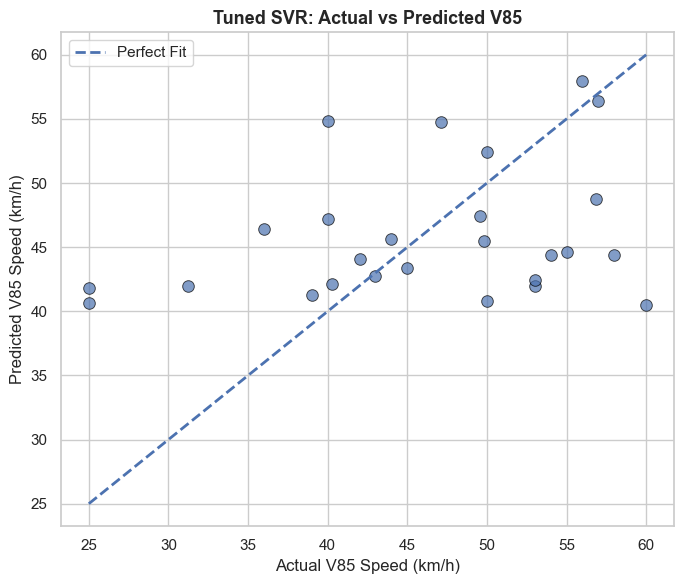

In [185]:
# ============================================================
# TUNED SVR: ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_svr_tuned,
    s=70,
    alpha=0.7,
    edgecolor="black"
)

min_val = min(
    y_test.min(),
    y_test_pred_svr_tuned.min()
)

max_val = max(
    y_test.max(),
    y_test_pred_svr_tuned.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel(
    "Actual V85 Speed (km/h)"
)

plt.ylabel(
    "Predicted V85 Speed (km/h)"
)

plt.title(
    "Tuned SVR: Actual vs Predicted V85",
    fontsize=13,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()
plt.show()

In [187]:
# ============================================================
# TUNED SVR RESIDUALS
# ============================================================

svr_tuned_residuals = (
    y_test.values
    - y_test_pred_svr_tuned
)

print(
    "Mean Test Residual:",
    round(
        np.mean(svr_tuned_residuals),
        3
    )
)

Mean Test Residual: 0.211


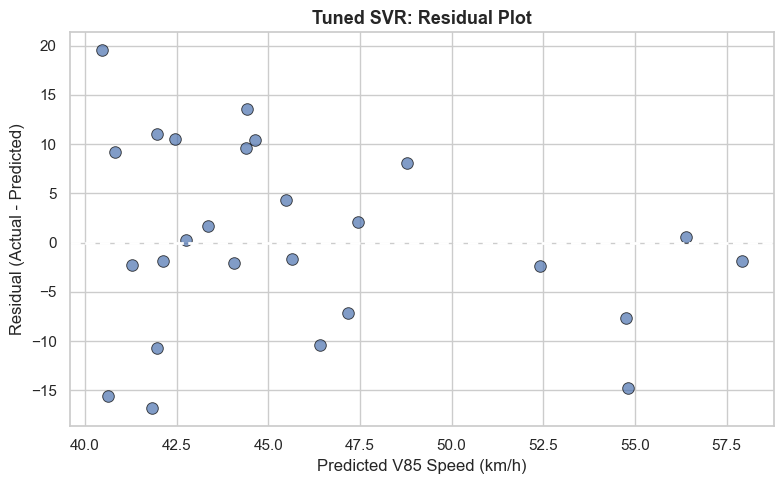

In [188]:
# ============================================================
# TUNED SVR RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test_pred_svr_tuned,
    y=svr_tuned_residuals,
    s=70,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Predicted V85 Speed (km/h)"
)

plt.ylabel(
    "Residual (Actual - Predicted)"
)

plt.title(
    "Tuned SVR: Residual Plot",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

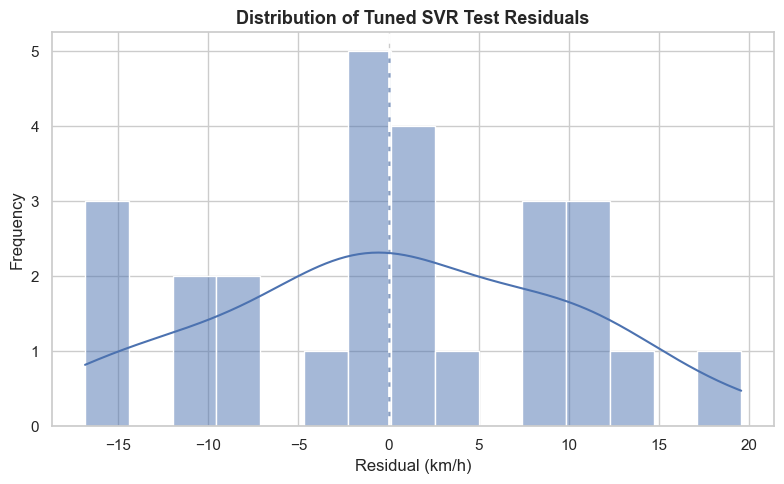

In [189]:
# ============================================================
# TUNED SVR RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    svr_tuned_residuals,
    bins=15,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Residual (km/h)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Tuned SVR Test Residuals",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [190]:
# ============================================================
# TUNED SVR PREDICTION TABLE
# ============================================================

svr_tuned_predictions = pd.DataFrame({

    "Actual V85":
        y_test.values,

    "Predicted V85":
        y_test_pred_svr_tuned,

    "Residual":
        svr_tuned_residuals,

    "Absolute Error":
        np.abs(
            svr_tuned_residuals
        )
})

display(
    svr_tuned_predictions.round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
0,58.00,44.41,13.59,13.59
1,56.00,57.92,-1.92,1.92
2,40.00,54.82,-14.82,14.82
3,40.25,42.11,-1.86,1.86
4,60.00,40.46,19.54,19.54
5,45.00,43.35,1.65,1.65
6,56.85,48.77,8.08,8.08
7,44.00,45.66,-1.66,1.66
8,49.80,45.47,4.33,4.33
9,39.00,41.27,-2.27,2.27


In [191]:
display(
    svr_tuned_predictions
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
4,60.00,40.46,19.54,19.54
17,25.00,41.83,-16.83,16.83
14,25.00,40.63,-15.63,15.63
2,40.00,54.82,-14.82,14.82
0,58.00,44.41,13.59,13.59
18,53.00,41.96,11.04,11.04
12,31.25,41.96,-10.71,10.71
19,53.00,42.46,10.54,10.54
13,36.00,46.42,-10.42,10.42
22,55.00,44.62,10.38,10.38


In [192]:
# ============================================================
# TOP SVR GRIDSEARCH RESULTS
# ============================================================

svr_cv_results = pd.DataFrame(
    grid_svr.cv_results_
)

svr_cv_summary = svr_cv_results[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    by="rank_test_score"
)

display(
    svr_cv_summary.head(10)
)

,params,mean_test_score,std_test_score,rank_test_score
102,"{'C': 10, 'epsilon': 1.0, 'gamma': 0.1, 'kerne...",0.042850,0.192767,1
90,"{'C': 10, 'epsilon': 0.5, 'gamma': 0.1, 'kerne...",0.036184,0.191662,2
96,"{'C': 10, 'epsilon': 1.0, 'gamma': 'scale', 'k...",0.032994,0.171822,3
78,"{'C': 10, 'epsilon': 0.1, 'gamma': 0.1, 'kerne...",0.030647,0.190464,4
135,"{'C': 100, 'epsilon': 1.0, 'gamma': 0.01, 'ker...",0.028888,0.211237,5
123,"{'C': 100, 'epsilon': 0.5, 'gamma': 0.01, 'ker...",0.014993,0.220113,6
133,"{'C': 100, 'epsilon': 1.0, 'gamma': 'scale', '...",0.013467,0.223384,7
139,"{'C': 100, 'epsilon': 1.0, 'gamma': 0.1, 'kern...",0.013467,0.223384,7
136,"{'C': 100, 'epsilon': 1.0, 'gamma': 0.01, 'ker...",0.013467,0.223384,7
142,"{'C': 100, 'epsilon': 1.0, 'gamma': 1.0, 'kern...",0.013467,0.223384,7


In [193]:
# ============================================================
# FINAL TUNED SVR RESULT
# ============================================================

svr_tuned_final = pd.DataFrame({

    "Model": [
        "Tuned SVR"
    ],

    "R2": [
        round(
            svr_tuned_test_r2,
            3
        )
    ],

    "RMSE": [
        round(
            svr_tuned_test_rmse,
            3
        )
    ],

    "MAE": [
        round(
            svr_tuned_test_mae,
            3
        )
    ]
})

display(
    svr_tuned_final
)

,Model,R2,RMSE,MAE
0,Tuned SVR,0.035,9.368,7.552


In [194]:
# ============================================================
# MODEL COMPARISON AFTER SVR
# ============================================================

model_comparison_after_svr = pd.DataFrame({

    "Model": [
        "Multiple Linear Regression",
        "Base Random Forest",
        "Tuned Random Forest",
        "Base XGBoost",
        "Tuned XGBoost",
        "Base SVR",
        "Tuned SVR"
    ],

    "Test R²": [
        mlr_test_r2,
        rf_test_r2,
        rf_tuned_test_r2,
        xgb_test_r2,
        xgb_tuned_test_r2,
        svr_test_r2,
        svr_tuned_test_r2
    ],

    "Test RMSE": [
        mlr_test_rmse,
        rf_test_rmse,
        rf_tuned_test_rmse,
        xgb_test_rmse,
        xgb_tuned_test_rmse,
        svr_test_rmse,
        svr_tuned_test_rmse
    ],

    "Test MAE": [
        mlr_test_mae,
        rf_test_mae,
        rf_tuned_test_mae,
        xgb_test_mae,
        xgb_tuned_test_mae,
        svr_test_mae,
        svr_tuned_test_mae
    ]
})

model_comparison_after_svr = (
    model_comparison_after_svr
    .sort_values(
        by="Test RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    model_comparison_after_svr.round(3)
)

,Model,Test R²,Test RMSE,Test MAE
0,Tuned XGBoost,0.429,7.209,5.506
1,Tuned Random Forest,0.387,7.467,6.017
2,Base Random Forest,0.304,7.959,6.157
3,Base XGBoost,0.118,8.959,6.374
4,Base SVR,0.112,8.988,7.307
5,Multiple Linear Regression,0.069,9.204,7.429
6,Tuned SVR,0.035,9.368,7.552


In [195]:
# ============================================================
# MODEL 8: BASE ARTIFICIAL NEURAL NETWORK
# ============================================================

from sklearn.neural_network import MLPRegressor

In [196]:
# ============================================================
# BASE ANN MODEL
# ============================================================

ann = MLPRegressor(
    random_state=42,
    max_iter=2000
)

print(ann)

MLPRegressor(max_iter=2000, random_state=42)


In [197]:
# ============================================================
# TRAIN BASE ANN
# ============================================================

ann.fit(
    X_train_scaled,
    y_train
)

print("Base ANN model trained successfully.")

Base ANN model trained successfully.


In [198]:
# ============================================================
# BASE ANN PREDICTIONS
# ============================================================

y_train_pred_ann = ann.predict(
    X_train_scaled
)

y_test_pred_ann = ann.predict(
    X_test_scaled
)

print("ANN predictions completed.")

ANN predictions completed.


In [200]:
# ============================================================
# BASE ANN TRAINING PERFORMANCE
# ============================================================

ann_train_r2 = r2_score(
    y_train,
    y_train_pred_ann
)

ann_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_ann
    )
)

ann_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_ann
)

In [201]:
# ============================================================
# BASE ANN TEST PERFORMANCE
# ============================================================

ann_test_r2 = r2_score(
    y_test,
    y_test_pred_ann
)

ann_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_ann
    )
)

ann_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_ann
)

In [202]:
# ============================================================
# BASE ANN PERFORMANCE SUMMARY
# ============================================================

print("=" * 55)
print("BASE ANN PERFORMANCE")
print("=" * 55)

print("\nTRAINING DATA")
print(f"R²   : {ann_train_r2:.4f}")
print(f"RMSE : {ann_train_rmse:.4f} km/h")
print(f"MAE  : {ann_train_mae:.4f} km/h")

print("\nTEST DATA")
print(f"R²   : {ann_test_r2:.4f}")
print(f"RMSE : {ann_test_rmse:.4f} km/h")
print(f"MAE  : {ann_test_mae:.4f} km/h")

BASE ANN PERFORMANCE

TRAINING DATA
R²   : 0.4029
RMSE : 8.1437 km/h
MAE  : 6.6802 km/h

TEST DATA
R²   : -0.0107
RMSE : 9.5882 km/h
MAE  : 8.0322 km/h


In [203]:
ann_performance = pd.DataFrame({

    "Dataset": [
        "Training",
        "Testing"
    ],

    "R²": [
        ann_train_r2,
        ann_test_r2
    ],

    "RMSE (km/h)": [
        ann_train_rmse,
        ann_test_rmse
    ],

    "MAE (km/h)": [
        ann_train_mae,
        ann_test_mae
    ]
})

display(
    ann_performance.round(3)
)

,Dataset,R²,RMSE (km/h),MAE (km/h)
0,Training,0.403,8.144,6.680
1,Testing,-0.011,9.588,8.032


In [204]:
# ============================================================
# ANN CONVERGENCE INFORMATION
# ============================================================

print(
    "Number of iterations used:",
    ann.n_iter_
)

print(
    "Final training loss:",
    round(ann.loss_, 4)
)

Number of iterations used: 2000
Final training loss: 33.1675


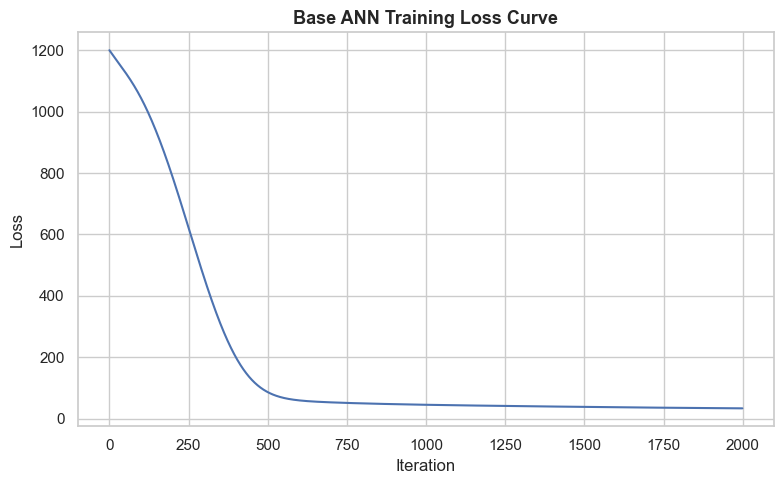

In [205]:
# ============================================================
# BASE ANN LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    ann.loss_curve_
)

plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.title(
    "Base ANN Training Loss Curve",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

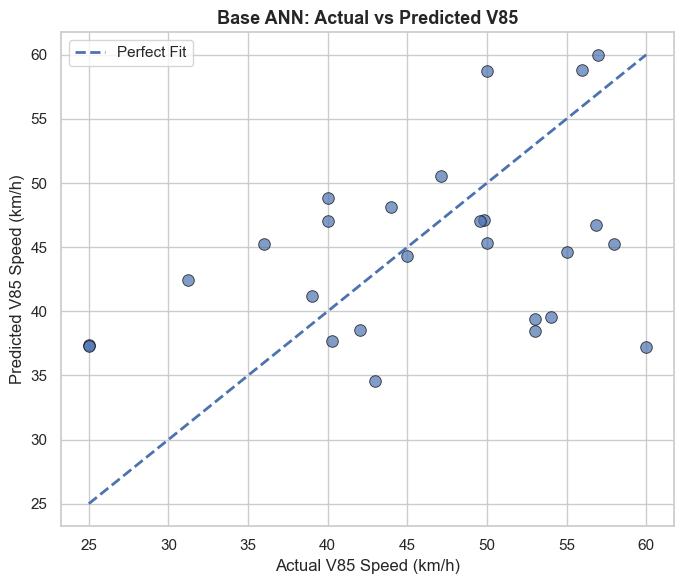

In [206]:
# ============================================================
# BASE ANN: ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_ann,
    s=70,
    alpha=0.7,
    edgecolor="black"
)

min_val = min(
    y_test.min(),
    y_test_pred_ann.min()
)

max_val = max(
    y_test.max(),
    y_test_pred_ann.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel(
    "Actual V85 Speed (km/h)"
)

plt.ylabel(
    "Predicted V85 Speed (km/h)"
)

plt.title(
    "Base ANN: Actual vs Predicted V85",
    fontsize=13,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()
plt.show()

In [207]:
# ============================================================
# BASE ANN RESIDUALS
# ============================================================

ann_residuals = (
    y_test.values
    - y_test_pred_ann
)

print(
    "Mean Test Residual:",
    round(
        np.mean(ann_residuals),
        3
    )
)

Mean Test Residual: 1.484


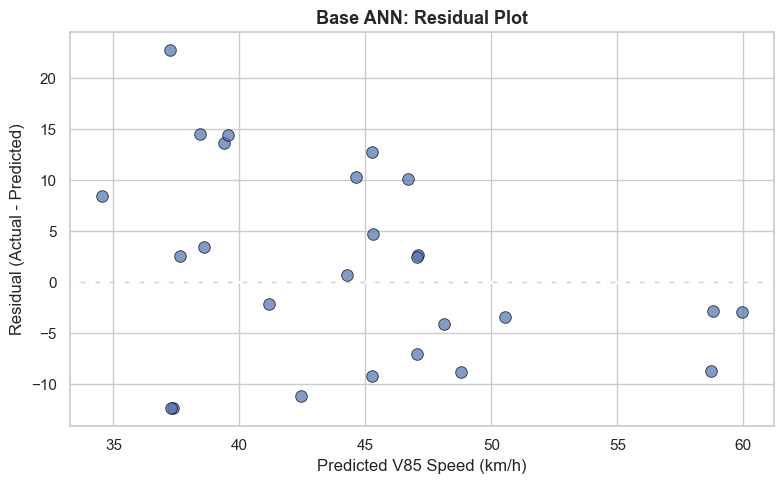

In [208]:
# ============================================================
# BASE ANN RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test_pred_ann,
    y=ann_residuals,
    s=70,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Predicted V85 Speed (km/h)"
)

plt.ylabel(
    "Residual (Actual - Predicted)"
)

plt.title(
    "Base ANN: Residual Plot",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

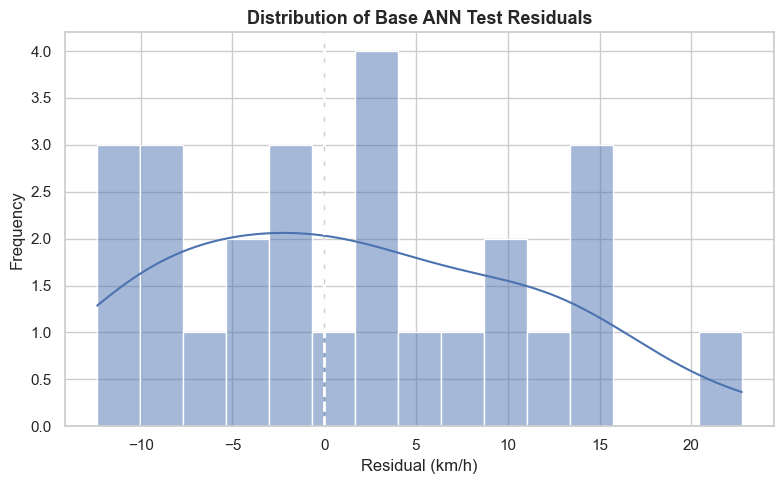

In [209]:
# ============================================================
# BASE ANN RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    ann_residuals,
    bins=15,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Residual (km/h)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Base ANN Test Residuals",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [210]:
# ============================================================
# BASE ANN PREDICTION TABLE
# ============================================================

ann_predictions = pd.DataFrame({

    "Actual V85":
        y_test.values,

    "Predicted V85":
        y_test_pred_ann,

    "Residual":
        ann_residuals,

    "Absolute Error":
        np.abs(ann_residuals)

})

display(
    ann_predictions.round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
0,58.00,45.27,12.73,12.73
1,56.00,58.79,-2.79,2.79
2,40.00,48.81,-8.81,8.81
3,40.25,37.66,2.59,2.59
4,60.00,37.25,22.75,22.75
5,45.00,44.28,0.72,0.72
6,56.85,46.70,10.15,10.15
7,44.00,48.11,-4.11,4.11
8,49.80,47.09,2.71,2.71
9,39.00,41.17,-2.17,2.17


In [211]:
display(
    ann_predictions
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
4,60.00,37.25,22.75,22.75
19,53.00,38.46,14.54,14.54
24,54.00,39.54,14.46,14.46
18,53.00,39.39,13.61,13.61
0,58.00,45.27,12.73,12.73
14,25.00,37.37,-12.37,12.37
17,25.00,37.29,-12.29,12.29
12,31.25,42.45,-11.20,11.20
22,55.00,44.63,10.37,10.37
6,56.85,46.70,10.15,10.15


In [212]:
# ============================================================
# FINAL BASE ANN RESULT
# ============================================================

ann_final = pd.DataFrame({

    "Model": [
        "Base ANN"
    ],

    "R2": [
        round(
            ann_test_r2,
            3
        )
    ],

    "RMSE": [
        round(
            ann_test_rmse,
            3
        )
    ],

    "MAE": [
        round(
            ann_test_mae,
            3
        )
    ]
})

display(ann_final)

,Model,R2,RMSE,MAE
0,Base ANN,-0.011,9.588,8.032


In [213]:
# ============================================================
# MODEL COMPARISON AFTER BASE ANN
# ============================================================

model_comparison_after_ann = pd.DataFrame({

    "Model": [
        "Multiple Linear Regression",
        "Base Random Forest",
        "Tuned Random Forest",
        "Base XGBoost",
        "Tuned XGBoost",
        "Base SVR",
        "Tuned SVR",
        "Base ANN"
    ],

    "Test R²": [
        mlr_test_r2,
        rf_test_r2,
        rf_tuned_test_r2,
        xgb_test_r2,
        xgb_tuned_test_r2,
        svr_test_r2,
        svr_tuned_test_r2,
        ann_test_r2
    ],

    "Test RMSE": [
        mlr_test_rmse,
        rf_test_rmse,
        rf_tuned_test_rmse,
        xgb_test_rmse,
        xgb_tuned_test_rmse,
        svr_test_rmse,
        svr_tuned_test_rmse,
        ann_test_rmse
    ],

    "Test MAE": [
        mlr_test_mae,
        rf_test_mae,
        rf_tuned_test_mae,
        xgb_test_mae,
        xgb_tuned_test_mae,
        svr_test_mae,
        svr_tuned_test_mae,
        ann_test_mae
    ]
})

model_comparison_after_ann = (
    model_comparison_after_ann
    .sort_values(
        by="Test RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    model_comparison_after_ann.round(3)
)

,Model,Test R²,Test RMSE,Test MAE
0,Tuned XGBoost,0.429,7.209,5.506
1,Tuned Random Forest,0.387,7.467,6.017
2,Base Random Forest,0.304,7.959,6.157
3,Base XGBoost,0.118,8.959,6.374
4,Base SVR,0.112,8.988,7.307
5,Multiple Linear Regression,0.069,9.204,7.429
6,Tuned SVR,0.035,9.368,7.552
7,Base ANN,-0.011,9.588,8.032


In [214]:
# ============================================================
# MODEL 9: HYPERPARAMETER-TUNED ANN
# ============================================================

param_grid_ann = {

    "hidden_layer_sizes": [
        (32,),
        (64,),
        (64, 32),
        (128, 64)
    ],

    "activation": [
        "relu",
        "tanh"
    ],

    "alpha": [
        0.0001,
        0.001,
        0.01
    ],

    "learning_rate_init": [
        0.001,
        0.01
    ]
}

print("ANN hyperparameter grid created successfully.")

ANN hyperparameter grid created successfully.


In [215]:
# ============================================================
# NUMBER OF ANN PARAMETER COMBINATIONS
# ============================================================

from math import prod

n_combinations_ann = prod(
    len(values)
    for values in param_grid_ann.values()
)

print(
    "Total hyperparameter combinations:",
    n_combinations_ann
)

print(
    "Total model fits using 5-fold CV:",
    n_combinations_ann * 5
)

Total hyperparameter combinations: 48
Total model fits using 5-fold CV: 240


In [216]:
# ============================================================
# CONFIGURE ANN GRIDSEARCHCV
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor

grid_ann = GridSearchCV(

    estimator=MLPRegressor(
        max_iter=3000,
        random_state=42
    ),

    param_grid=param_grid_ann,

    cv=5,

    scoring="r2",

    n_jobs=-1,

    verbose=1
)

print("ANN GridSearchCV configured successfully.")

ANN GridSearchCV configured successfully.


In [217]:
# ============================================================
# TUNE ANN USING TRAINING DATA ONLY
# ============================================================

grid_ann.fit(
    X_train_scaled,
    y_train
)

print("\nANN tuning completed.")

print("\nBest Parameters:")
print(grid_ann.best_params_)

print(
    "\nBest Mean 5-Fold CV R²:",
    round(
        grid_ann.best_score_,
        3
    )
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits

ANN tuning completed.

Best Parameters:
{'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.001}

Best Mean 5-Fold CV R²: 0.014


In [218]:
# ============================================================
# EXTRACT BEST ANN
# ============================================================

best_ann = grid_ann.best_estimator_

print("Best ANN:")
print(best_ann)

Best ANN:
MLPRegressor(activation='tanh', alpha=0.01, hidden_layer_sizes=(32,),
             max_iter=3000, random_state=42)


In [219]:
# ============================================================
# EXTRACT BEST ANN
# ============================================================

best_ann = grid_ann.best_estimator_

print("Best ANN:")
print(best_ann)

Best ANN:
MLPRegressor(activation='tanh', alpha=0.01, hidden_layer_sizes=(32,),
             max_iter=3000, random_state=42)


In [223]:
# ============================================================
# BEST ANN PARAMETERS TABLE
# ============================================================

best_ann_params = pd.DataFrame(
    list(
        grid_ann.best_params_.items()
    ),
    columns=[
        "Parameter",
        "Best Value"
    ]
)

display(best_ann_params)

,Parameter,Best Value
0,activation,tanh
1,alpha,0.01
2,hidden_layer_sizes,"(32,)"
3,learning_rate_init,0.001


In [226]:
# ============================================================
# TUNED ANN PREDICTIONS
# ============================================================

# Best ANN model obtained from GridSearchCV
best_ann = grid_ann.best_estimator_

# Training predictions
y_train_pred_ann_tuned = best_ann.predict(
    X_train_scaled
)

# Testing predictions
y_test_pred_ann_tuned = best_ann.predict(
    X_test_scaled
)

print("Tuned ANN predictions generated successfully.")

print("Training predictions:", len(y_train_pred_ann_tuned))
print("Testing predictions :", len(y_test_pred_ann_tuned))

Tuned ANN predictions generated successfully.
Training predictions: 104
Testing predictions : 26


In [227]:
# ============================================================
# TUNED ANN TRAINING PERFORMANCE
# ============================================================

ann_tuned_train_r2 = r2_score(
    y_train,
    y_train_pred_ann_tuned
)

ann_tuned_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_ann_tuned
    )
)

ann_tuned_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_ann_tuned
)

In [228]:
# ============================================================
# TUNED ANN TEST PERFORMANCE
# ============================================================

ann_tuned_test_r2 = r2_score(
    y_test,
    y_test_pred_ann_tuned
)

ann_tuned_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_ann_tuned
    )
)

ann_tuned_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_ann_tuned
)

In [229]:
ann_tuned_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Value": [
        ann_tuned_test_r2,
        ann_tuned_test_rmse,
        ann_tuned_test_mae
    ]
})

display(
    ann_tuned_results.round(3)
)

,Metric,Value
0,R2,-0.037
1,RMSE,9.713
2,MAE,7.429


In [230]:
# ============================================================
# TRAINING VS TESTING PERFORMANCE
# ============================================================

ann_tuned_performance = pd.DataFrame({

    "Dataset": [
        "Training",
        "Testing"
    ],

    "R²": [
        ann_tuned_train_r2,
        ann_tuned_test_r2
    ],

    "RMSE (km/h)": [
        ann_tuned_train_rmse,
        ann_tuned_test_rmse
    ],

    "MAE (km/h)": [
        ann_tuned_train_mae,
        ann_tuned_test_mae
    ]
})

display(
    ann_tuned_performance.round(3)
)

,Dataset,R²,RMSE (km/h),MAE (km/h)
0,Training,0.385,8.264,6.685
1,Testing,-0.037,9.713,7.429


In [231]:
print("=" * 60)
print("TUNED ANN PERFORMANCE")
print("=" * 60)

print("\nTRAINING DATA")
print(f"R²   : {ann_tuned_train_r2:.4f}")
print(f"RMSE : {ann_tuned_train_rmse:.4f} km/h")
print(f"MAE  : {ann_tuned_train_mae:.4f} km/h")

print("\nTEST DATA")
print(f"R²   : {ann_tuned_test_r2:.4f}")
print(f"RMSE : {ann_tuned_test_rmse:.4f} km/h")
print(f"MAE  : {ann_tuned_test_mae:.4f} km/h")

print("\nBEST 5-FOLD CV R²")
print(f"{grid_ann.best_score_:.4f}")

TUNED ANN PERFORMANCE

TRAINING DATA
R²   : 0.3851
RMSE : 8.2642 km/h
MAE  : 6.6846 km/h

TEST DATA
R²   : -0.0372
RMSE : 9.7133 km/h
MAE  : 7.4288 km/h

BEST 5-FOLD CV R²
0.0136


In [232]:
ann_final = pd.DataFrame({

    "Model": ["ANN"],

    "R2": [
        round(
            ann_test_r2,
            3
        )
    ],

    "RMSE": [
        round(
            ann_test_rmse,
            3
        )
    ],

    "MAE": [
        round(
            ann_test_mae,
            3
        )
    ]
})

In [233]:
ann_tuned_final = pd.DataFrame({

    "Model": [
        "Tuned ANN"
    ],

    "R2": [
        round(
            ann_tuned_test_r2,
            3
        )
    ],

    "RMSE": [
        round(
            ann_tuned_test_rmse,
            3
        )
    ],

    "MAE": [
        round(
            ann_tuned_test_mae,
            3
        )
    ]
})

In [234]:
# ============================================================
# BASE ANN VS TUNED ANN
# ============================================================

ann_comparison = pd.concat(
    [
        ann_final,
        ann_tuned_final
    ],
    ignore_index=True
)

display(ann_comparison)

,Model,R2,RMSE,MAE
0,ANN,-0.011,9.588,8.032
1,Tuned ANN,-0.037,9.713,7.429


In [235]:
ann_detailed_comparison = pd.DataFrame({

    "Model": [
        "Base ANN",
        "Tuned ANN"
    ],

    "Training R²": [
        ann_train_r2,
        ann_tuned_train_r2
    ],

    "Test R²": [
        ann_test_r2,
        ann_tuned_test_r2
    ],

    "Test RMSE": [
        ann_test_rmse,
        ann_tuned_test_rmse
    ],

    "Test MAE": [
        ann_test_mae,
        ann_tuned_test_mae
    ]
})

display(
    ann_detailed_comparison.round(3)
)

,Model,Training R²,Test R²,Test RMSE,Test MAE
0,Base ANN,0.403,-0.011,9.588,8.032
1,Tuned ANN,0.385,-0.037,9.713,7.429


In [236]:
# ============================================================
# IMPROVEMENT AFTER ANN TUNING
# ============================================================

ann_r2_improvement = (
    ann_tuned_test_r2
    - ann_test_r2
)

ann_rmse_reduction = (
    ann_test_rmse
    - ann_tuned_test_rmse
)

ann_mae_reduction = (
    ann_test_mae
    - ann_tuned_test_mae
)

print("=" * 50)
print("IMPROVEMENT AFTER ANN TUNING")
print("=" * 50)

print(
    f"R² improvement : "
    f"{ann_r2_improvement:+.3f}"
)

print(
    f"RMSE reduction : "
    f"{ann_rmse_reduction:+.3f} km/h"
)

print(
    f"MAE reduction  : "
    f"{ann_mae_reduction:+.3f} km/h"
)

IMPROVEMENT AFTER ANN TUNING
R² improvement : -0.027
RMSE reduction : -0.125 km/h
MAE reduction  : +0.603 km/h


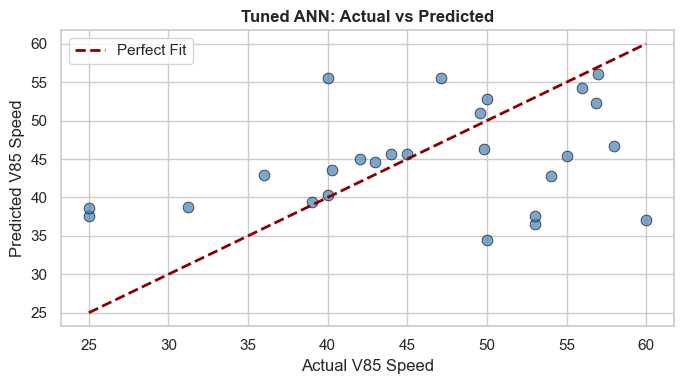

In [237]:
# ============================================================
# TUNED ANN: ACTUAL VS PREDICTED
# ============================================================

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_ann_tuned,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

# Perfect-fit line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel(
    "Actual V85 Speed"
)

plt.ylabel(
    "Predicted V85 Speed"
)

plt.title(
    "Tuned ANN: Actual vs Predicted",
    fontsize=12,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()
plt.show()

In [238]:
# ============================================================
# TUNED ANN RESIDUALS
# ============================================================

ann_tuned_residuals = (
    y_test
    - y_test_pred_ann_tuned
)

print(
    "Mean Test Residual:",
    round(
        np.mean(ann_tuned_residuals),
        3
    )
)

Mean Test Residual: 1.283


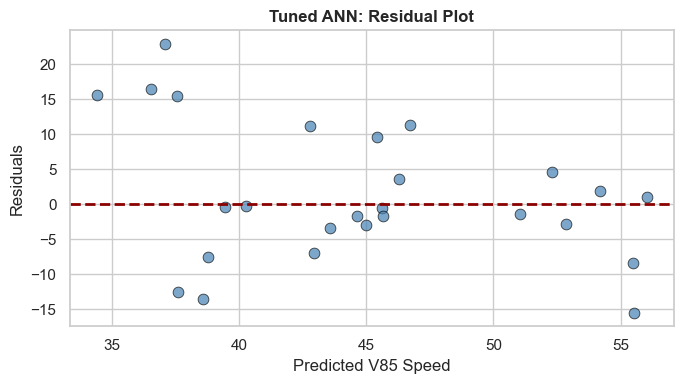

In [239]:
# ============================================================
# TUNED ANN RESIDUAL PLOT
# ============================================================

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test_pred_ann_tuned,
    y=ann_tuned_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(
    y=0,
    linestyle="--",
    color="darkred",
    linewidth=2
)

plt.xlabel(
    "Predicted V85 Speed"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Tuned ANN: Residual Plot",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

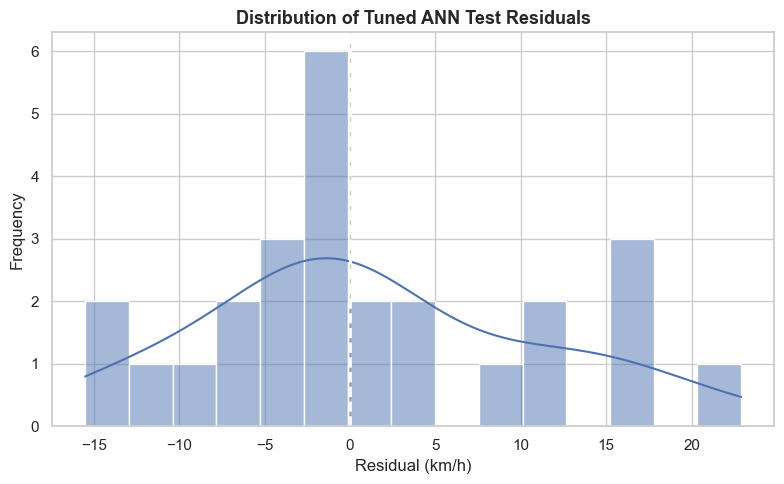

In [240]:
plt.figure(figsize=(8, 5))

sns.histplot(
    ann_tuned_residuals,
    bins=15,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Residual (km/h)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Tuned ANN Test Residuals",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

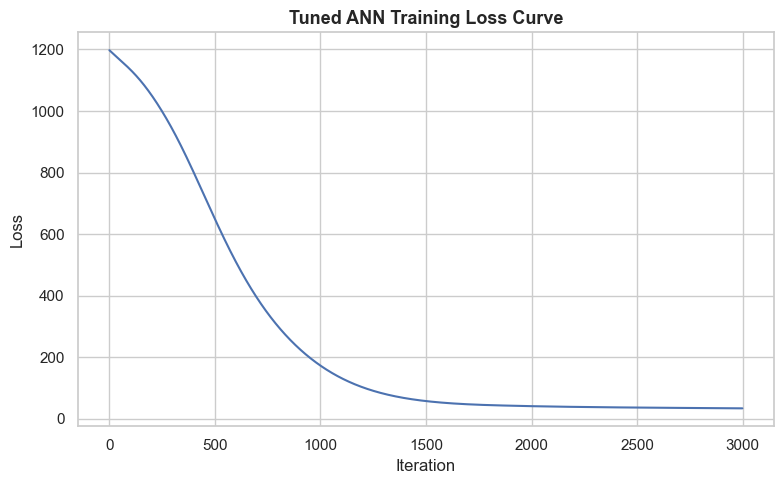

In [241]:
# ============================================================
# TUNED ANN LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    best_ann.loss_curve_
)

plt.xlabel(
    "Iteration"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Tuned ANN Training Loss Curve",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [242]:
print(
    "Iterations used:",
    best_ann.n_iter_
)

print(
    "Final loss:",
    round(
        best_ann.loss_,
        4
    )
)

Iterations used: 3000
Final loss: 34.1602


In [243]:
# ============================================================
# TUNED ANN PREDICTION TABLE
# ============================================================

ann_tuned_predictions = pd.DataFrame({

    "Actual V85":
        y_test.values,

    "Predicted V85":
        y_test_pred_ann_tuned,

    "Residual":
        np.array(
            ann_tuned_residuals
        ),

    "Absolute Error":
        np.abs(
            np.array(
                ann_tuned_residuals
            )
        )
})

display(
    ann_tuned_predictions.round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
0,58.00,46.73,11.27,11.27
1,56.00,54.19,1.81,1.81
2,40.00,55.51,-15.51,15.51
3,40.25,43.59,-3.34,3.34
4,60.00,37.10,22.90,22.90
5,45.00,45.62,-0.62,0.62
6,56.85,52.31,4.54,4.54
7,44.00,45.66,-1.66,1.66
8,49.80,46.28,3.52,3.52
9,39.00,39.47,-0.47,0.47


In [244]:
display(
    ann_tuned_predictions
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .round(2)
)

,Actual V85,Predicted V85,Residual,Absolute Error
4,60.00,37.10,22.90,22.90
18,53.00,36.56,16.44,16.44
10,50.00,34.42,15.58,15.58
2,40.00,55.51,-15.51,15.51
19,53.00,37.56,15.44,15.44
17,25.00,38.58,-13.58,13.58
14,25.00,37.60,-12.60,12.60
0,58.00,46.73,11.27,11.27
24,54.00,42.80,11.20,11.20
22,55.00,45.44,9.56,9.56


In [245]:
# ============================================================
# TOP ANN HYPERPARAMETER COMBINATIONS
# ============================================================

ann_cv_results = pd.DataFrame(
    grid_ann.cv_results_
)

ann_cv_summary = ann_cv_results[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    by="rank_test_score"
)

display(
    ann_cv_summary.head(10)
)

,params,mean_test_score,std_test_score,rank_test_score
40,"{'activation': 'tanh', 'alpha': 0.01, 'hidden_...",0.013622,0.190323,1
32,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",0.013597,0.190335,2
24,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.013595,0.190336,3
44,"{'activation': 'tanh', 'alpha': 0.01, 'hidden_...",0.005590,0.264449,4
28,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.003531,0.264543,5
36,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",0.003171,0.264853,6
37,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",-0.023925,0.190330,7
29,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",-0.026002,0.232022,8
30,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",-0.083007,0.320439,9
38,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",-0.083373,0.320806,10


In [246]:
# ============================================================
# FINAL COMPARISON OF ALL MODELS
# ============================================================

final_model_comparison = pd.DataFrame({

    "Model": [
        "Multiple Linear Regression",
        "Base Random Forest",
        "Tuned Random Forest",
        "Advanced Tuned RF",
        "Base XGBoost",
        "Tuned XGBoost",
        "Base SVR",
        "Tuned SVR",
        "Base ANN",
        "Tuned ANN"
    ],

    "R²": [
        mlr_test_r2,
        rf_test_r2,
        rf_tuned_test_r2,
        rf_adv_test_r2,
        xgb_test_r2,
        xgb_tuned_test_r2,
        svr_test_r2,
        svr_tuned_test_r2,
        ann_test_r2,
        ann_tuned_test_r2
    ],

    "RMSE (km/h)": [
        mlr_test_rmse,
        rf_test_rmse,
        rf_tuned_test_rmse,
        rf_adv_test_rmse,
        xgb_test_rmse,
        xgb_tuned_test_rmse,
        svr_test_rmse,
        svr_tuned_test_rmse,
        ann_test_rmse,
        ann_tuned_test_rmse
    ],

    "MAE (km/h)": [
        mlr_test_mae,
        rf_test_mae,
        rf_tuned_test_mae,
        rf_adv_test_mae,
        xgb_test_mae,
        xgb_tuned_test_mae,
        svr_test_mae,
        svr_tuned_test_mae,
        ann_test_mae,
        ann_tuned_test_mae
    ]
})

# Rank primarily according to RMSE
final_model_comparison = (
    final_model_comparison
    .sort_values(
        by="RMSE (km/h)",
        ascending=True
    )
    .reset_index(drop=True)
)

# Add rank
final_model_comparison.insert(
    0,
    "Rank",
    range(1, len(final_model_comparison) + 1)
)

display(
    final_model_comparison.round(3)
)

NameError: name 'rf_adv_test_r2' is not defined